<a href="https://colab.research.google.com/github/Aaron-coderson/Categorizing-Cyber-Attacks/blob/main/draft/newCyberPaper.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Setting Up

In [1]:
#import packages
import pandas as pd
import numpy as np
import seaborn as sns
import plotly
import matplotlib.pyplot as plt
import plotly.express as px
import numpy as np
import plotly.graph_objects as go

In [2]:
# clone self to acess data
!git clone https://github.com/Aaron-coderson/Categorizing-Cyber-Attacks.git


Cloning into 'Categorizing-Cyber-Attacks'...
remote: Enumerating objects: 31, done.
remote: Counting objects: 100% (31/31), done.
remote: Compressing objects: 100% (30/30), done.
remote: Total 31 (delta 8), reused 11 (delta 1), pack-reused 0 (from 0)
Receiving objects: 100% (31/31), 5.28 MiB | 6.55 MiB/s, done.
Resolving deltas: 100% (8/8), done.


In [3]:
!ls

Categorizing-Cyber-Attacks  sample_data


In [1]:
# import cissm data to df
df = pd.read_csv("data/cissm_data.csv", encoding="latin-1")

NameError: name 'pd' is not defined

In [5]:
# save copy for backup
original_df = df

# Data Processing

In [6]:
## event_counts stores cyber event types over all indsustries
event_counts = df.groupby('event_type').size().reset_index(name='counts')
event_counts

,event_type,counts
0,Disruptive,4360
1,Exploitive,7000
2,Mixed,2500
3,Undetermined,181


In [7]:
## motive_counts stores motive over all industries
motive_counts = df.groupby('motive').size().reset_index(name='counts')
motive_counts

,motive,counts
0,Financial,8034
1,Industrial-Espionage,94
2,Personal Attack,93
3,Political-Espionage,679
4,Protest,1680
5,"Protest,Financial",1
6,Protest;Political-Espionage,1
7,Sabotage,340
8,Undetermined,3119


In [8]:
## actor_counts stores actor types over all industries
actor_counts = df.groupby('actor_type').size().reset_index(name='counts')
actor_counts

,actor_type,counts
0,Criminal,10676
1,Hacktivist,1909
2,Hacktvist,17
3,Hobbyist,191
4,Nation-State,803
5,Terrorist,30
6,Undetermined,415


In [9]:
## monthly counts stores month, event_type, and industry
monthly_counts = df.groupby(['month', 'event_type', 'industry']).size().reset_index(name='count')

In [10]:
## dfEventType stores occurrences of each event type within each industry
dfEventType = df.groupby('industry')['event_type'].value_counts().unstack(fill_value=0)

# Rename columns for clarity
dfEventType = dfEventType.rename(columns={
    'Undetermined': 'undetermined_eventType_count',
    'Mixed': 'mixed_eventType_count',
    'Exploitive': 'exploititive_eventType_count',
    'Disruptive': 'disruptive_eventType_count'
})

# Calculate total counts for each industry
dfEventType['industry_counts'] = dfEventType.sum(axis=1)

# Reset index to make 'industry' a regular column
dfEventType = dfEventType.reset_index()

# Sort dfEventType by industry_counts in ascending order
dfEventType = dfEventType.sort_values(by='industry_counts', ascending=True)
dfEventType.head()

event_type,industry,disruptive_eventType_count,exploititive_eventType_count,mixed_eventType_count,undetermined_eventType_count,industry_counts
12,Medusa,0,0,1,0,1
2,"Agriculture, Forestry, Fishing and Hunting",6,3,9,0,18
10,Management of Companies and Enterprises,5,8,7,0,20
8,Health Care and Social Services,4,11,11,1,27
4,Construction,9,10,27,1,47


In [11]:
## dfActorType stores occurences of each actor_type within each industry
dfActorType = df.groupby('industry')['actor_type'].value_counts().unstack(fill_value=0)
dfActorType['industry_counts'] = dfActorType.sum(axis=1)
dfActorType = dfActorType.reset_index()
dfActorType = dfActorType.sort_values(by='industry_counts', ascending=True)
dfActorType.head()

actor_type,industry,Criminal,Hacktivist,Hacktvist,Hobbyist,Nation-State,Terrorist,Undetermined,industry_counts
12,Medusa,1,0,0,0,0,0,0,1
2,"Agriculture, Forestry, Fishing and Hunting",13,4,0,0,1,0,0,18
10,Management of Companies and Enterprises,16,2,0,0,2,0,0,20
8,Health Care and Social Services,27,0,0,0,0,0,0,27
4,Construction,39,7,0,1,0,0,0,47


In [12]:
## dfMotive stores occurrences of each motive type within each industry
dfMotive = df.groupby('industry')['motive'].value_counts().unstack(fill_value=0)
dfMotive['industry_counts'] = dfMotive.sum(axis=1)
dfMotive = dfMotive.reset_index()
dfMotive = dfMotive.sort_values(by='industry_counts', ascending=True)
dfMotive.rename(columns = {'industry': 'Sector Title', 'Undetermined': 'Undetermined Motive'}, inplace = True)
dfMotive.head()

motive,Sector Title,Financial,Industrial-Espionage,Personal Attack,Political-Espionage,Protest,"Protest,Financial",Protest;Political-Espionage,Sabotage,Undetermined Motive,industry_counts
12,Medusa,1,0,0,0,0,0,0,0,0,1
2,"Agriculture, Forestry, Fishing and Hunting",10,0,0,0,4,0,0,1,3,18
10,Management of Companies and Enterprises,13,0,0,1,2,0,0,1,3,20
8,Health Care and Social Services,27,0,0,0,0,0,0,0,0,27
4,Construction,34,0,0,0,8,0,0,0,5,47


In [13]:
## combine dfEventType, dfActorType, and dfMotive type into final merged df

dfActorType = dfActorType.sort_values(by='industry_counts', ascending=True)
dfEventType = dfEventType.sort_values(by='industry_counts', ascending=True)
dfMotive = dfMotive.sort_values(by='industry_counts', ascending=True)
dfActorType.rename(columns = {'industry': 'Sector Title'}, inplace = True)
dfEventType.rename(columns = {'industry': 'Sector Title'}, inplace = True)
dfMotive.rename(columns = {'industry': 'Sector Title'}, inplace = True)

merged_df = pd.merge(dfEventType, dfActorType, on='Sector Title', how='outer')
final_merged_df = pd.merge(merged_df, dfMotive, on='Sector Title', how='outer')
final_merged_df = final_merged_df.sort_values(by='industry_counts_y', ascending=True)
final_merged_df.head()

,Sector Title,disruptive_eventType_count,exploititive_eventType_count,mixed_eventType_count,undetermined_eventType_count,industry_counts_x,Criminal,Hacktivist,Hacktvist,Hobbyist,...,Financial,Industrial-Espionage,Personal Attack,Political-Espionage,Protest,"Protest,Financial",Protest;Political-Espionage,Sabotage,Undetermined Motive,industry_counts
12,Medusa,0,0,1,0,1,1,0,0,0,...,1,0,0,0,0,0,0,0,0,1
2,"Agriculture, Forestry, Fishing and Hunting",6,3,9,0,18,13,4,0,0,...,10,0,0,0,4,0,0,1,3,18
10,Management of Companies and Enterprises,5,8,7,0,20,16,2,0,0,...,13,0,0,1,2,0,0,1,3,20
8,Health Care and Social Services,4,11,11,1,27,27,0,0,0,...,27,0,0,0,0,0,0,0,0,27
4,Construction,9,10,27,1,47,39,7,0,1,...,34,0,0,0,8,0,0,0,5,47


In [14]:
## create lists of values for certain columns for use throughout
listEvent = [ 'disruptive_count',
 'exploitive_count',
 'mixed_count',
 'undetermined_count']

listActor = ['Criminal',
 'Hacktivist',
 'Hobbyist',
 'Nation-State',
 'Terrorist',
 'Undetermined']

listMotive =  ['Financial',
 'Industrial-Espionage',
 'Personal Attack',
 'Political-Espionage',
 'Protest',
 'Protest,Financial',
 'Protest;Political-Espionage',
 'Sabotage',
 'Undetermined Motive']

industry_types = [ "Agriculture, Forestry, Fishing and Hunting"
 "Mining",
 "Utilities",
 "Construction",
 "Manufacturing",
 "Wholesale Trade",
 "Retail Trade",
 "Transportation and Warehousing",
 "Information",
 "Finance and Insurance",
 "Real Estate Rental and Leasing",
 "Professional, Scientific, and Technical Services",
 "Management of Companies and Enterprises",
 "Administrative and Support and Waste Management and Remediation Services",
 "Educational Services",
 "Health Care and Social Assistance",
 "Arts, Entertainment, and Recreation",
 "Accommodation and Food Services",
 "Other Services (except Public Administration)",
 "Public Administration"]


In [15]:
## create industryDF which stores event_date, industry, and counts
## create timeDF which stores event_date and counts

df['event_date'] = pd.to_datetime(df['event_date'], format = 'mixed')

event_types = ['Undetermined', 'Disruptive', 'Exploitive', 'Mixed']
filtered_df = df[df['event_type'].isin(event_types)]

timeDf = filtered_df.groupby([pd.Grouper(key='event_date', freq='M')]).size().reset_index(name='counts')

# Convert event_date to datetime
df['event_date'] = pd.to_datetime(df['event_date'])

# Filter rows based on event_type values
event_types = ['Undetermined', 'Disruptive', 'Exploitive', 'Mixed']
filtered_df = df[df['event_type'].isin(event_types)]

# Group by year, month, and event_type, then count occurrences
grouped_df = filtered_df.groupby([pd.Grouper(key='event_date', freq='M'), 'event_type']).size().reset_index(name='counts')


filtered_df = df[df['industry'].isin(industry_types)]

# Group by year, month, and event_type, then count occurrences
industryDf = filtered_df.groupby([pd.Grouper(key='event_date', freq='ME'), 'industry']).size().reset_index(name='counts')

<ipython-input-15-2cdf16e3cd52>:9: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  timeDf = filtered_df.groupby([pd.Grouper(key='event_date', freq='M')]).size().reset_index(name='counts')
<ipython-input-15-2cdf16e3cd52>:19: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  grouped_df = filtered_df.groupby([pd.Grouper(key='event_date', freq='M'), 'event_type']).size().reset_index(name='counts')


In [16]:
# df_health contains only the data of attacks on the Health Care and Social Assistance industr
df_health = df[df['industry'] == 'Health Care and Social Assistance']

In [17]:
# df_publicAdmin contains only data of attacks on the Public Adminsitration Industry
df_publicAdmin = df[df['industry'] == 'Public Administration']

# Analysis Over All Industries

# Distribution of Cyber Events over All Industries


In [18]:
import plotly.express as px
import plotly.graph_objects as go

fig = px.bar(df, y=df['industry'].value_counts().index, x=df['industry'].value_counts().values,
             title='Distribution of Cyber Attacks Across Industries')

fig.update_layout(
    width=800,
    height=600,
    yaxis_title="Industry",
    xaxis_title="Number of Attacks"

)

fig.update_layout(font=dict(size=14))
fig.show()
# this code graphs the number of cyber attacks per industry using plotly

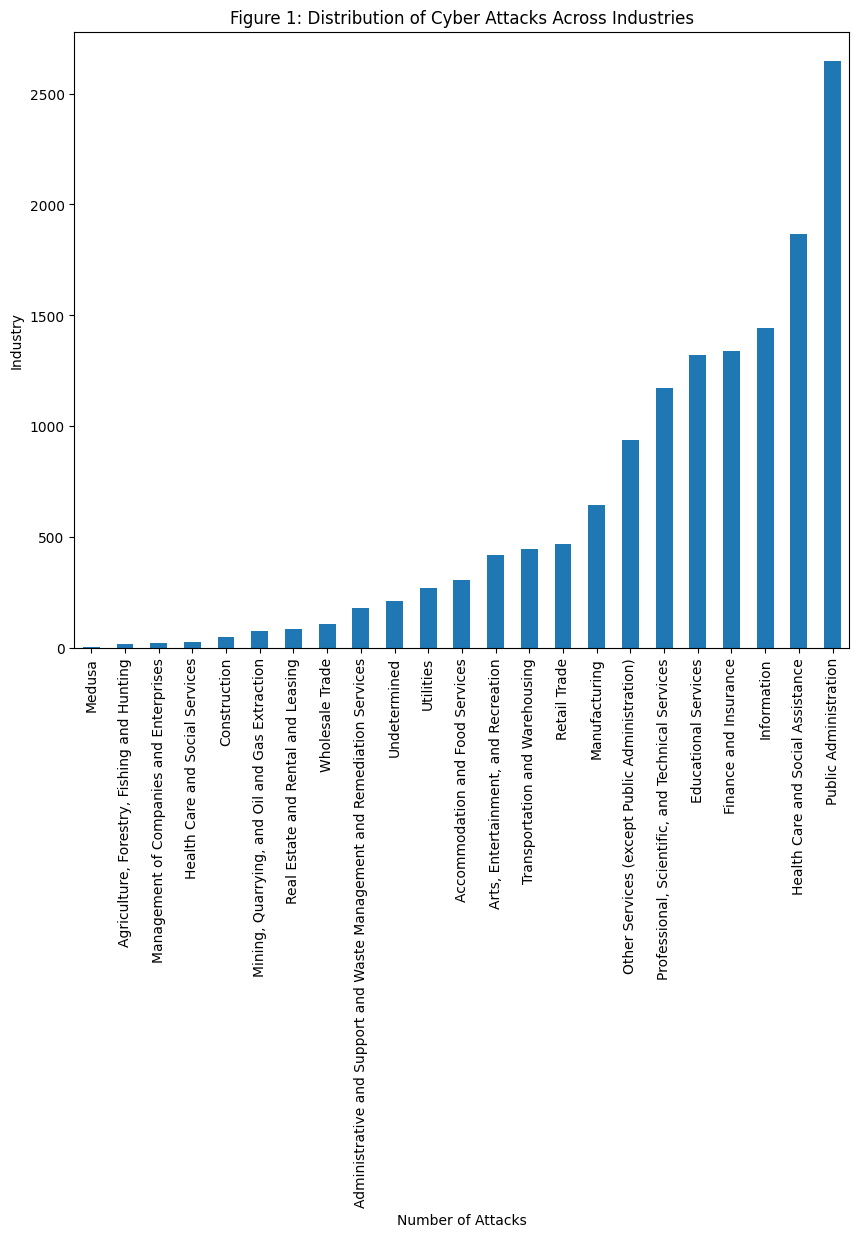

In [19]:
industry_counts = df['industry'].value_counts().sort_values(ascending=True)
plt.figure(figsize=(10, 8))
industry_counts.plot(kind='bar')
plt.xlabel('Number of Attacks')
plt.ylabel('Industry')
_ = plt.title('Figure 1: Distribution of Cyber Attacks Across Industries')
# this code graphs the number of cyber attacks per industry using Matplotlib

# Cyber Event Types over All Industries

In [20]:
fig = px.bar(event_counts,
             y='event_type',
             x='counts',
             orientation='h',
             color_discrete_sequence=px.colors.qualitative.Dark2,
             labels={'event_type': 'Event Type', 'counts': 'Number of Attacks'},
             title='Distribution of Cyber Attacks by Event Type Across All Industries')

fig.update_layout(
    yaxis_title='Event Type',
    xaxis_title='Number of Attacks',
    showlegend=False,
    plot_bgcolor='white'
)
fig.update_layout(font=dict(size=14))
fig.show()
# this code graphs the distribution of cyber attack event types across all industries using plotly

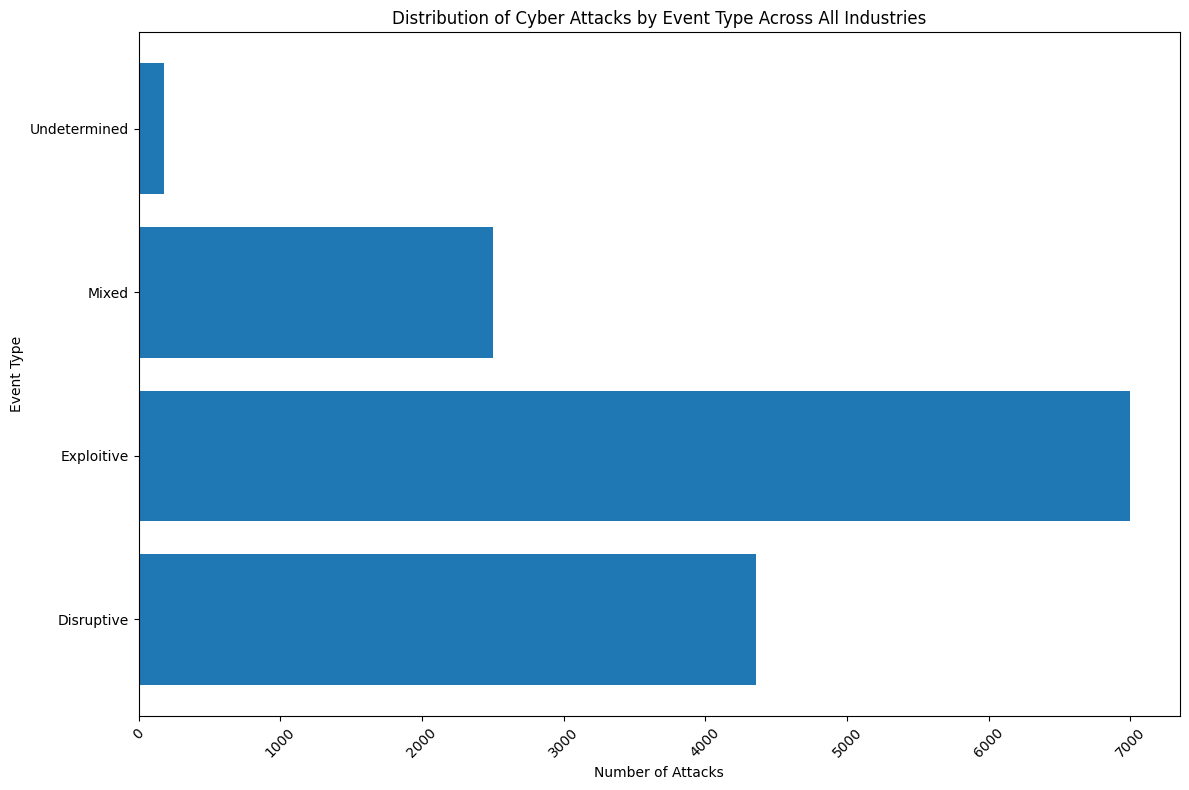

In [21]:
fig, ax = plt.subplots(figsize=(12, 8))

ax.barh(event_counts['event_type'], event_counts['counts'])

ax.set_xlabel('Number of Attacks')
ax.set_ylabel('Event Type')
ax.set_title('Distribution of Cyber Attacks by Event Type Across All Industries')

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

# this code graphs the distribution of cyber attack event types across all industries using Matplotlib

In [22]:
fig = px.bar(dfEventType, y = "Sector Title",
             x = ["disruptive_eventType_count", "exploititive_eventType_count",
                  "mixed_eventType_count", "undetermined_eventType_count"],
                  title = "Distribution of Cyber Events and Types Across Industries" )
fig.update_layout(font=dict(size=14))
fig.show()
# graph cyber events across all industry as well as coloring by event-type

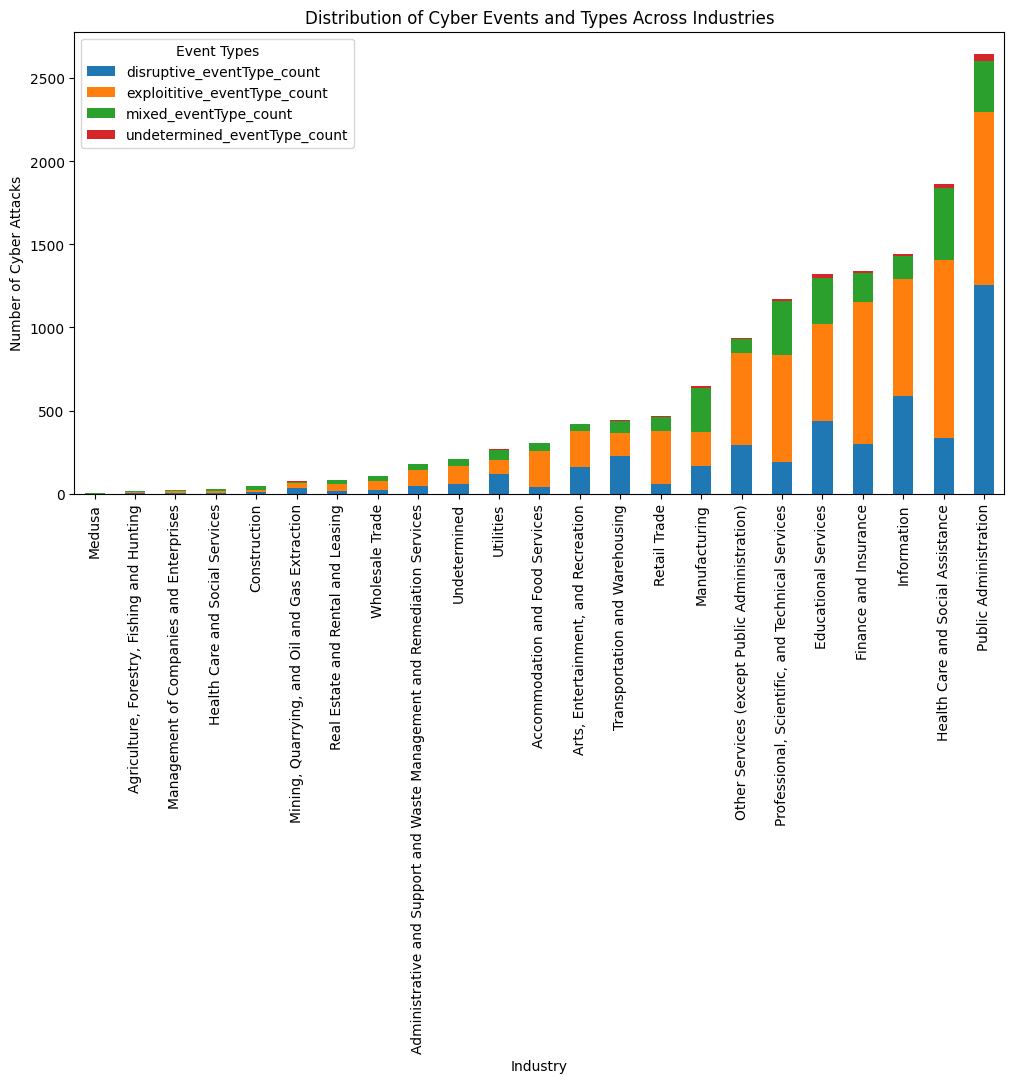

In [23]:
dfEventType[['disruptive_eventType_count', 'exploititive_eventType_count', 'mixed_eventType_count', 'undetermined_eventType_count']].plot(kind='bar', stacked=True, figsize=(12, 6))
plt.title('Distribution of Cyber Events and Types Across Industries')
plt.xlabel('Industry')
plt.ylabel('Number of Cyber Attacks')
plt.xticks(range(len(dfEventType)), dfEventType['Sector Title'], rotation=90)
_ = plt.legend(title='Event Types')
#plt.show()

In [24]:
import plotly.graph_objects as go

fig = go.Figure(data=go.Heatmap(
    z=dfEventType[["disruptive_eventType_count", "exploititive_eventType_count", "mixed_eventType_count", "undetermined_eventType_count"]].values,
    x=["disruptive_eventType_count", "exploititive_eventType_count", "mixed_eventType_count", "undetermined_eventType_count"],
    y=dfEventType["Sector Title"], colorscale="tempo"
   ))

fig.update_layout(title='Heatmap of Event Types by Industry')
fig.update_layout(font=dict(size=14))
fig.show()
# graph heatmap of industry vs event_type for cyber events

In [25]:
fig = px.pie(event_counts, values='counts', names='event_type', title = 'Pie Chart of Cyber Event Types')
fig.update_layout(font=dict(size=14))
fig.show()

# Motives of Cyber Event Types over all Industries

In [26]:
fig = px.pie(motive_counts, values='counts', names='motive', title = 'Pie Chart of Motives')
fig.update_layout(font=dict(size=14))
fig.show()
# pie chart of motives over all industries

In [27]:
fig = px.bar(dfMotive, y = "Sector Title",
             x = listMotive,
                  title = "Distribution of Motive Types Across Industries" )

fig.show()
# graph cyber events across all industry as well as coloring by event-type

In [28]:
fig = go.Figure(data=go.Heatmap(
    z=final_merged_df[listMotive].values,
    x=listMotive,
    y=final_merged_df["Sector Title"], colorscale="tempo"
   ))

fig.update_layout(title='Heatmap of Motive Types by Sector Title')

fig.show()
# graph heatmap of industry vs event_type for cyber events

In [29]:
fig = px.bar(motive_counts, y = 'motive',
             x = 'counts',
             orientation = 'h',
             color_discrete_sequence=px.colors.qualitative.Dark2,
             labels={'motive': 'Motive Counts', 'counts': 'Number of Attacks'},
             title='Distribution of Cyber Attacks by Motive Type Across All Industries')

fig.update_layout(
    yaxis_title='Event Type',
    xaxis_title='Number of Attacks',
    showlegend=False,
    plot_bgcolor='white'
)

fig.update_layout(font=dict(size=14))
fig.show()
# this code graphs the distribution of cyber attack actor types across all industries

# Actor Types of Cyber Events over all Industries

In [30]:
fig = px.pie(actor_counts, values='counts', names='actor_type', title = 'Pie Chart of Actor Types')
fig.update_layout(font=dict(size=14))
fig.show()

In [31]:
import plotly.graph_objects as go

fig = go.Figure(data=go.Heatmap(
    z=dfActorType[listActor].values,
    x=listActor,
    y=dfActorType["Sector Title"], colorscale="tempo"
   ))

fig.update_layout(title='Heatmap of Actor Types by Industry')

fig.show()
# graph heatmap of industry vs event_type for cyber events

In [32]:
fig = px.bar(dfActorType, y = "Sector Title",
             x = listActor,
                  title = "Distribution of Actor Types Across Industries" )

fig.show()
# graph cyber events across all industry as well as coloring by actor type

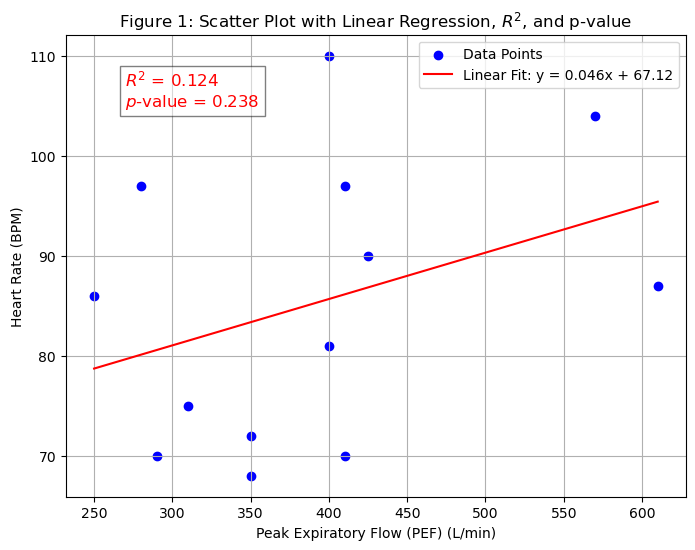

In [3]:
import matplotlib.pyplot as plt
import numpy as np
import scipy.stats as stats

# Data points
PEF = np.array([250, 280, 290, 310, 350, 350, 400, 400, 410, 410, 425, 570, 610])
Heart_Rate = np.array([86, 97, 70, 75, 68, 72, 81, 110, 70, 97, 90, 104, 87])

# Perform linear regression
slope, intercept, r_value, p_value, _ = stats.linregress(PEF, Heart_Rate)
line = PEF * slope + intercept  # Compute trendline values

# Plot scatter plot with trendline
plt.figure(figsize=(8, 6))
plt.scatter(PEF, Heart_Rate, color="blue", label="Data Points")
plt.plot(
    PEF, line, color="red", label=f"Linear Fit: y = {slope:.3f}x + {intercept:.2f}"
)

# Add R-squared and p-value to the plot
plt.text(
    min(PEF) + 20,
    max(Heart_Rate) - 5,
    f"$R^2$ = {r_value**2:.3f}\n$p$-value = {p_value:.3f}",
    fontsize=12,
    color="red",
    bbox=dict(facecolor="white", alpha=0.5),
)

# Labels and title
plt.xlabel("Peak Expiratory Flow (PEF) (L/min)")
plt.ylabel("Heart Rate (BPM)")
plt.title("Figure 1: Scatter Plot with Linear Regression, $R^2$, and p-value")
plt.legend()
plt.grid(True)
plt.show()


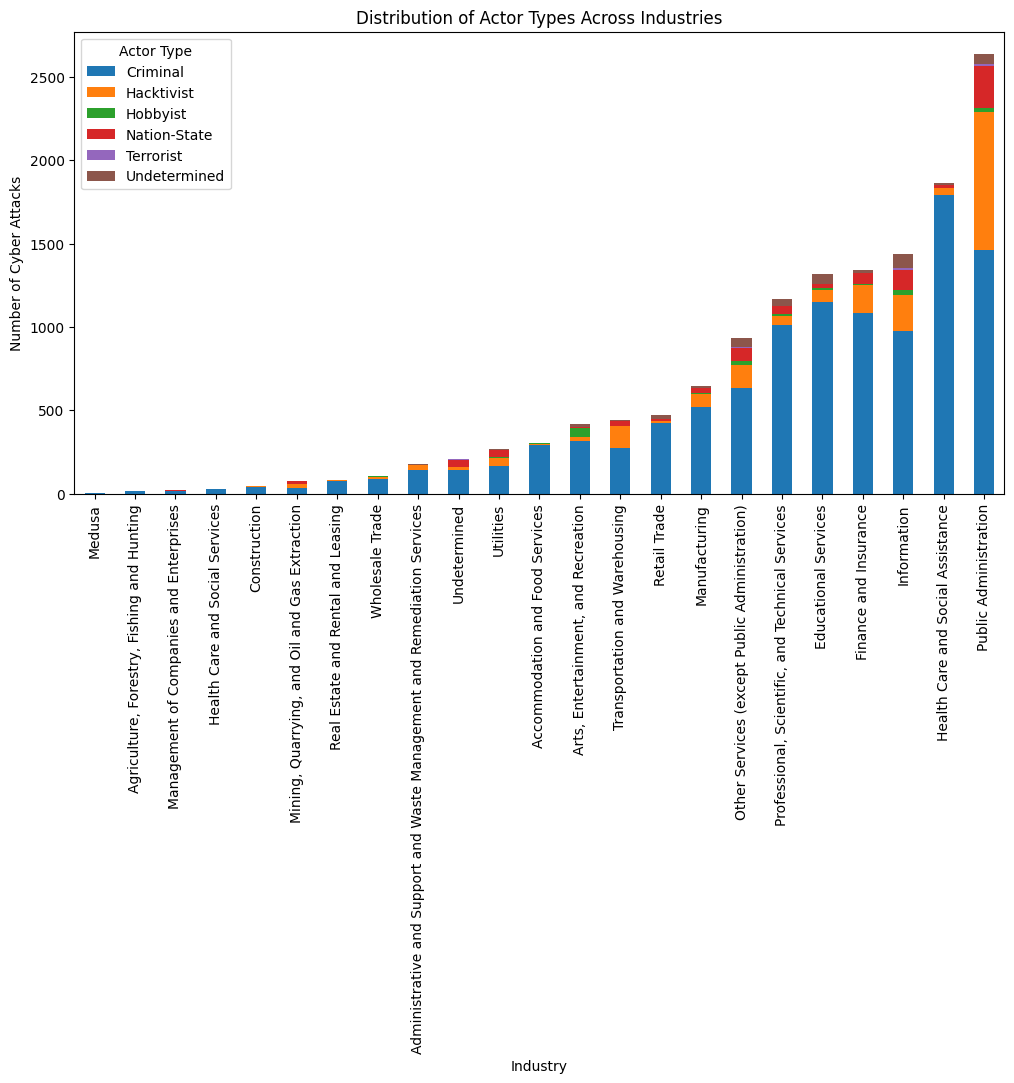

In [33]:
import matplotlib.pyplot as plt
import pandas as pd


dfActorType[['Criminal', 'Hacktivist', 'Hobbyist', 'Nation-State', 'Terrorist', 'Undetermined']].plot(kind='bar', stacked=True, figsize=(12, 6))
plt.title('Distribution of Actor Types Across Industries')
plt.xlabel('Industry')
plt.ylabel('Number of Cyber Attacks')
plt.xticks(range(len(dfActorType)), dfActorType['Sector Title'], rotation=90)
_ = plt.legend(title='Actor Type')
#plt.show()

In [34]:
fig = px.bar(actor_counts, y = 'actor_type',
             x = 'counts',
             orientation = 'h',
             color_discrete_sequence=px.colors.qualitative.Dark2,
             labels={'actor_type': 'Actor Type', 'counts': 'Number of Attacks'},
             title='Distribution of Cyber Attacks by Actor Type Across All Industries')

fig.update_layout(
    yaxis_title='Event Type',
    xaxis_title='Number of Attacks',
    showlegend=False,
    plot_bgcolor='white'
)

fig.update_layout(font=dict(size=14))
fig.show()
# this code graphs the distribution of cyber attack actor types across all industries

# Visualizations Over Time

<ipython-input-35-3712b40e2cc3>:9: FutureWarning:

'M' is deprecated and will be removed in a future version, please use 'ME' instead.



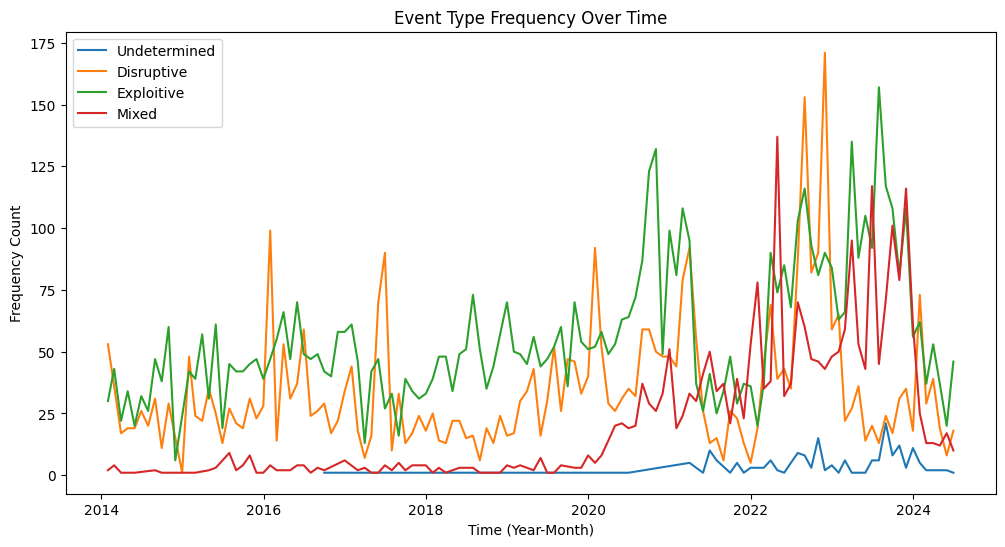

In [35]:
# Convert event_date to datetime
df['event_date'] = pd.to_datetime(df['event_date'], format = 'mixed')

# Filter rows based on event_type values
event_types = ['Undetermined', 'Disruptive', 'Exploitive', 'Mixed']
filtered_df = df[df['event_type'].isin(event_types)]

# Group by year, month, and event_type, then count occurrences
grouped_df = filtered_df.groupby([pd.Grouper(key='event_date', freq='M'), 'event_type']).size().reset_index(name='counts')

# Plot the data
plt.figure(figsize=(12, 6))

for event_type in event_types:
    subset_df = grouped_df[grouped_df['event_type'] == event_type]
    plt.plot(subset_df['event_date'], subset_df['counts'], label=event_type)

plt.xlabel('Time (Year-Month)')
plt.ylabel('Frequency Count')
plt.title('Event Type Frequency Over Time')
plt.legend()

plt.show()
# this code graphs each cyber event frequency over time in terms of month(s)

In [36]:
fig = px.line(grouped_df, x='event_date', y='counts', color='event_type', title='Event Type Frequency Over Time')

fig.update_xaxes(title_text='Time (Year-Month)')
fig.update_yaxes(title_text='Frequency Count')
fig.update_layout(font=dict(size=14))

fig.show()
# this code graphs each cyber event frequency over time in terms of month(s)

In [37]:
fig = px.line(timeDf, x='event_date', y='counts',  title='All Over Time')

fig.update_xaxes(title_text='Time (Year-Month)')
fig.update_yaxes(title_text='Frequency Count')

fig.update_layout(font=dict(size=14))
fig.show()
# this code graphs each cyber event frequency over time in terms of month(s)

In [38]:
from plotly.express import scatter
fig.update_layout(font=dict(size=14))
scatter(data_frame=grouped_df, x='event_date', y='counts', color='event_type', trendline='lowess', trendline_scope='trace')

In [39]:
fig = px.line(industryDf, x='event_date', y='counts', color='industry', title='Cyber Attacks over Time by Industry')

fig.update_xaxes(title_text='Time (Year-Month)')
fig.update_yaxes(title_text='Frequency Count')
fig.update_layout(font=dict(size=14))
fig.show()
# this code graphs each cyber event frequency over time in terms of month(s)

In [40]:
fig = px.bar(industryDf, x='event_date', y='counts', color='industry', title='Cyber Attacks over Time by Industry')
fig.update_layout(font=dict(size=14))
fig.show()

In [41]:
fig = px.bar(monthly_counts, x='month', y='count', color='industry', title='Cyber Attacks over Time by Industry')
fig.update_layout(font=dict(size=14))
fig.show()

# Visualization of Healthcare

In [42]:
event_counts = df_health.groupby('event_type').size().reset_index(name='counts')

fig = px.bar(event_counts,
             y='event_type',
             x='counts',
             orientation='h',
             color_discrete_sequence=px.colors.qualitative.Dark2,
             labels={'event_type': 'Event Type', 'count': 'Number of Attacks'},
             title='Distribution of Cyber Attacks by Event Type in Health Care and Social Assistance Cyber Events')

fig.update_layout(
    yaxis_title='Event Type',
    xaxis_title='Number of Attacks',
    showlegend=False,
    plot_bgcolor='white'
)

fig.show()
# graphs the distribution of cyber attacks by event type in the Health Care and Social Assistance Industry

# Visualization of Public Administration

In [43]:
import plotly.express as px

event_counts = df_publicAdmin.groupby('event_type').size().reset_index(name='counts')

fig = px.bar(event_counts,
             y='event_type',
             x='counts',
             orientation='h',
             color_discrete_sequence=px.colors.qualitative.Dark2,
             labels={'event_type': 'Event Type', 'count': 'Number of Attacks'},
             title='Distribution of Cyber Attacks by Event Type in Public Administration Cyber Events')

fig.update_layout(
    yaxis_title='Event Type',
    xaxis_title='Number of Attacks',
    showlegend=False,
    plot_bgcolor='white'
)

fig.show()
#  graphs the distribution of cyber attacks by event type in the Public Administration Industry

# Stats

In [44]:
df_2023 = df[pd.to_datetime(df['event_date']).dt.year == 2023]

# Group by industry_code and count cyber events in 2024
cyber_events_2023 = df_2023.groupby('industry')['event_type'].count().reset_index()
cyber_events_2023.rename(columns={'event_type': 'cyber_events_2023'}, inplace=True)

In [45]:
df_2022 = df[pd.to_datetime(df['event_date']).dt.year == 2022]
cyber_events_2022 = df_2022.groupby('industry')['event_type'].count().reset_index()
cyber_events_2022.rename(columns = {'event_type': 'cyber_events_2022'}, inplace=True)
cyber_events_2022.rename(columns = {'industry': 'Sector Title'}, inplace = True)

In [46]:
df_2021 = df[pd.to_datetime(df['event_date']).dt.year == 2021]
cyber_events_2021 = df_2021.groupby('industry')['event_type'].count().reset_index()
cyber_events_2021.rename(columns = {'event_type': 'cyber_events_2021'}, inplace=True)
cyber_events_2021.rename(columns = {'industry': 'Sector Title'}, inplace = True)

In [47]:
df_2020 = df[pd.to_datetime(df['event_date']).dt.year == 2020]
cyber_events_2020 = df_2020.groupby('industry')['event_type'].count().reset_index()
cyber_events_2020.rename(columns = {'event_type': 'cyber_events_2020'}, inplace=True)
cyber_events_2020.rename(columns = {'industry': 'Sector Title'}, inplace = True)

In [48]:
df_2020.describe()

,event_date,year,month,industry_code
count,1747,1747.0,1747.000000,1747.000000
mean,2020-07-21 08:12:05.357756160,2020.0,7.136806,64.031483
min,2020-01-02 00:00:00,2020.0,1.000000,11.000000
25%,2020-04-23 00:00:00,2020.0,4.000000,52.000000
50%,2020-08-11 00:00:00,2020.0,8.000000,61.000000
75%,2020-10-16 12:00:00,2020.0,10.000000,81.000000
max,2020-12-31 00:00:00,2020.0,12.000000,99.000000
std,NaN,0.0,3.480950,17.574115


In [49]:
df_2021.describe()

,event_date,year,month,industry_code
count,1430,1430.0,1430.000000,1430.000000
mean,2021-05-31 12:44:18.461538304,2021.0,5.497203,61.146154
min,2021-01-01 00:00:00,2021.0,1.000000,11.000000
25%,2021-03-01 00:00:00,2021.0,3.000000,51.000000
50%,2021-05-04 00:00:00,2021.0,5.000000,61.000000
75%,2021-09-02 00:00:00,2021.0,9.000000,62.000000
max,2021-12-31 00:00:00,2021.0,12.000000,99.000000
std,NaN,0.0,3.484595,18.113600


In [50]:
df_2022.describe()

,event_date,year,month,industry_code
count,2562,2562.0,2562.000000,2562.000000
mean,2022-07-20 08:06:44.683840768,2022.0,7.134660,60.137783
min,2022-01-01 00:00:00,2022.0,1.000000,11.000000
25%,2022-04-24 00:00:00,2022.0,4.000000,51.000000
50%,2022-08-01 12:00:00,2022.0,8.000000,54.000000
75%,2022-10-11 18:00:00,2022.0,10.000000,72.000000
max,2022-12-31 00:00:00,2022.0,12.000000,99.000000
std,NaN,0.0,3.220792,20.383998


In [51]:
df_2023.describe()

,event_date,year,month,industry_code
count,2464,2464.000000,2464.000000,2464.000000
mean,2023-07-06 03:29:13.246753280,2023.000812,6.644886,59.468750
min,2023-01-01 00:00:00,2023.000000,1.000000,11.000000
25%,2023-04-04 18:00:00,2023.000000,4.000000,52.000000
50%,2023-07-11 00:00:00,2023.000000,7.000000,56.000000
75%,2023-09-30 00:00:00,2023.000000,9.000000,62.000000
max,2023-12-31 00:00:00,2024.000000,12.000000,99.000000
std,NaN,0.028484,3.335623,17.448394


In [52]:
merged_df.describe()

,disruptive_eventType_count,exploititive_eventType_count,mixed_eventType_count,undetermined_eventType_count,industry_counts_x,Criminal,Hacktivist,Hacktvist,Hobbyist,Nation-State,Terrorist,Undetermined,industry_counts_y
count,23.000000,23.000000,23.000000,23.000000,23.000000,23.000000,23.000000,23.000000,23.000000,23.000000,23.000000,23.000000,23.000000
mean,189.565217,304.347826,108.695652,7.869565,610.478261,464.173913,83.000000,0.739130,8.304348,34.913043,1.304348,18.043478,610.478261
std,280.617635,349.814835,125.432138,10.528336,709.142496,525.161850,173.248114,1.711389,13.586206,56.552400,3.363369,25.180220,709.142496
min,0.000000,0.000000,1.000000,0.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,20.000000,35.000000,27.500000,1.000000,78.500000,57.000000,7.500000,0.000000,0.000000,1.500000,0.000000,1.000000,78.500000
50%,57.000000,136.000000,43.000000,4.000000,306.000000,272.000000,23.000000,0.000000,2.000000,14.000000,0.000000,5.000000,306.000000
75%,260.000000,569.000000,155.500000,9.000000,1053.500000,804.500000,73.000000,1.000000,9.500000,44.000000,0.500000,19.000000,1053.500000
max,1253.000000,1070.000000,436.000000,44.000000,2648.000000,1794.000000,830.000000,8.000000,55.000000,252.000000,14.000000,84.000000,2648.000000


# Country

# Regraphing for Clarity

In [ ]:
final_merged_df

,Sector Title,disruptive_eventType_count,exploititive_eventType_count,mixed_eventType_count,undetermined_eventType_count,industry_counts_x,Criminal,Hacktivist,Hacktvist,Hobbyist,...,Financial,Industrial-Espionage,Personal Attack,Political-Espionage,Protest,"Protest,Financial",Protest;Political-Espionage,Sabotage,Undetermined Motive,industry_counts
12,Medusa,0,0,1,0,1,1,0,0,0,...,1,0,0,0,0,0,0,0,0,1
2,"Agriculture, Forestry, Fishing and Hunting",6,3,9,0,18,13,4,0,0,...,10,0,0,0,4,0,0,1,3,18
10,Management of Companies and Enterprises,5,8,7,0,20,16,2,0,0,...,13,0,0,1,2,0,0,1,3,20
8,Health Care and Social Services,4,11,11,1,27,27,0,0,0,...,27,0,0,0,0,0,0,0,0,27
4,Construction,9,10,27,1,47,39,7,0,1,...,34,0,0,0,8,0,0,0,5,47
13,"Mining, Quarrying, and Oil and Gas Extraction",32,30,10,1,73,36,23,0,0,...,27,1,0,2,26,0,0,8,9,73
17,Real Estate and Rental and Leasing,16,40,28,0,84,75,6,0,0,...,63,0,0,0,5,0,0,1,15,84
22,Wholesale Trade,24,52,29,2,107,87,15,0,2,...,78,1,0,0,15,0,0,0,13,107
1,Administrative and Support and Waste Managemen...,45,96,35,3,179,143,27,1,0,...,126,3,0,2,27,0,0,0,21,179
20,Undetermined,56,112,39,2,209,141,18,0,0,...,114,8,0,36,16,0,0,7,28,209


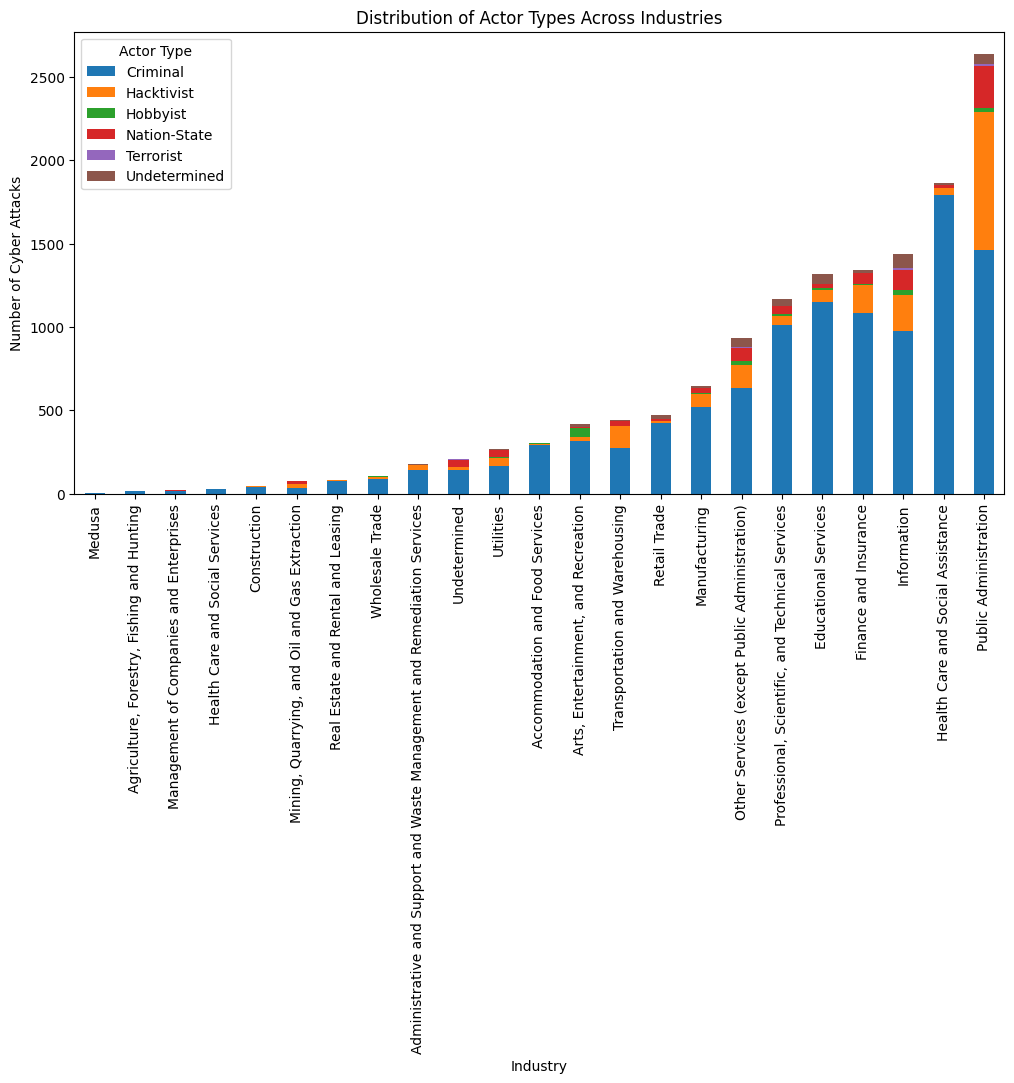

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd


dfActorType[['Criminal', 'Hacktivist', 'Hobbyist', 'Nation-State', 'Terrorist', 'Undetermined']].plot(kind='bar', stacked=True, figsize=(12, 6))
plt.title('Distribution of Actor Types Across Industries')
plt.xlabel('Industry')
plt.ylabel('Number of Cyber Attacks')
plt.xticks(range(len(dfActorType)), dfActorType['Sector Title'], rotation=90)
_ = plt.legend(title='Actor Type')
#plt.show()

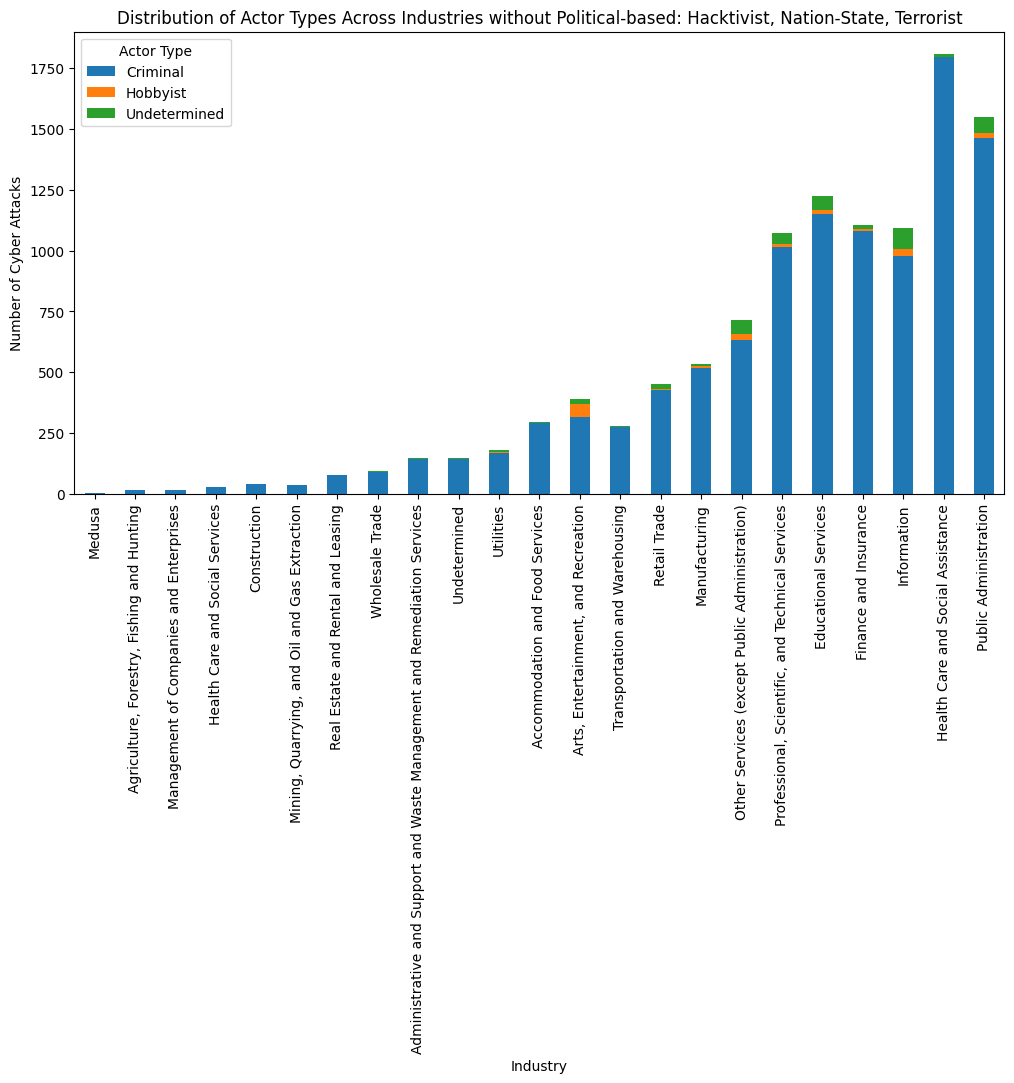

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd


dfActorType[['Criminal', 'Hobbyist', 'Undetermined']].plot(kind='bar', stacked=True, figsize=(12, 6))
plt.title('Distribution of Actor Types Across Industries without Political-based: Hacktivist, Nation-State, Terrorist')
plt.xlabel('Industry')
plt.ylabel('Number of Cyber Attacks')
plt.xticks(range(len(dfActorType)), dfActorType['Sector Title'], rotation=90)
_ = plt.legend(title='Actor Type')
#plt.show()

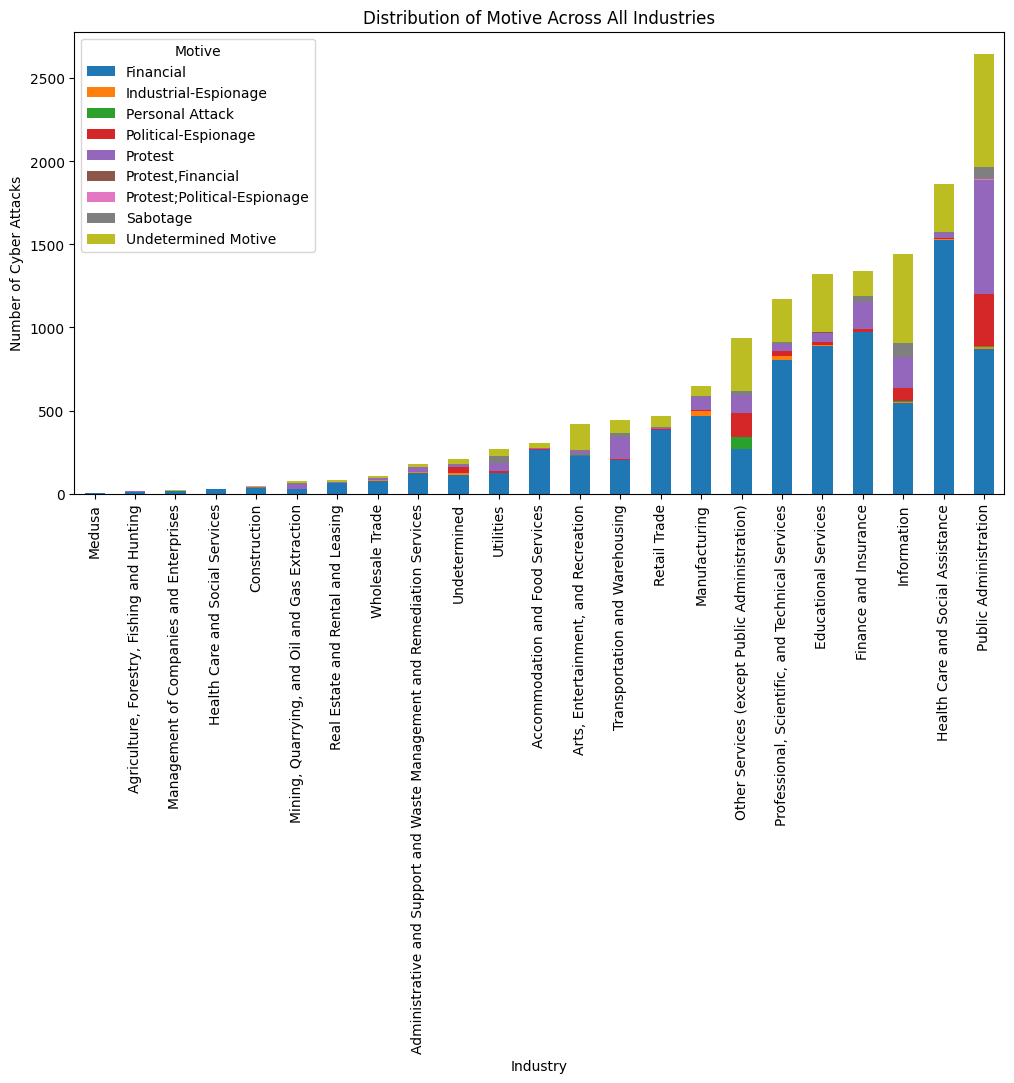

In [ ]:
dfMotive[['Financial'	,'Industrial-Espionage'	,'Personal Attack'	,'Political-Espionage'	,'Protest'	,'Protest,Financial'	,'Protest;Political-Espionage'	,'Sabotage'	,'Undetermined Motive']].plot(kind='bar', stacked=True, figsize=(12, 6))
plt.title('Distribution of Motive Across All Industries')
plt.xlabel('Industry')
plt.ylabel('Number of Cyber Attacks')
plt.xticks(range(len(dfActorType)), dfActorType['Sector Title'], rotation=90)
_ = plt.legend(title='Motive')

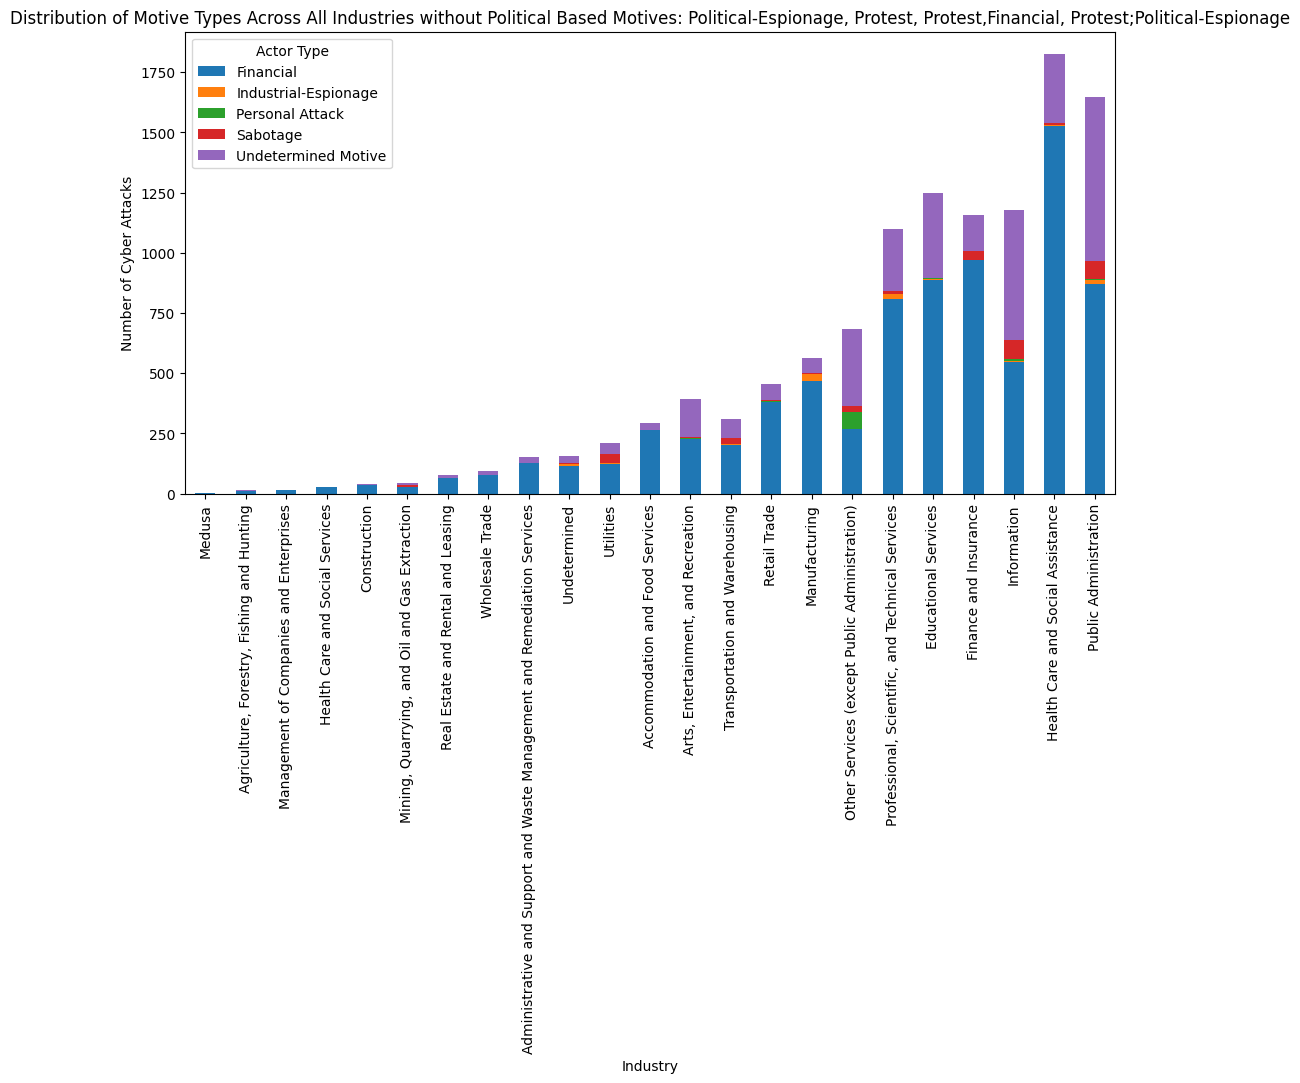

In [ ]:
dfMotive[['Financial'	,'Industrial-Espionage'	,'Personal Attack','Sabotage'	,'Undetermined Motive']].plot(kind='bar', stacked=True, figsize=(12, 6))
plt.title('Distribution of Motive Types Across All Industries without Political Based Motives: Political-Espionage, Protest, Protest,Financial, Protest;Political-Espionage')
plt.xlabel('Industry')
plt.ylabel('Number of Cyber Attacks')
plt.xticks(range(len(dfActorType)), dfActorType['Sector Title'], rotation=90)
_ = plt.legend(title='Actor Type')

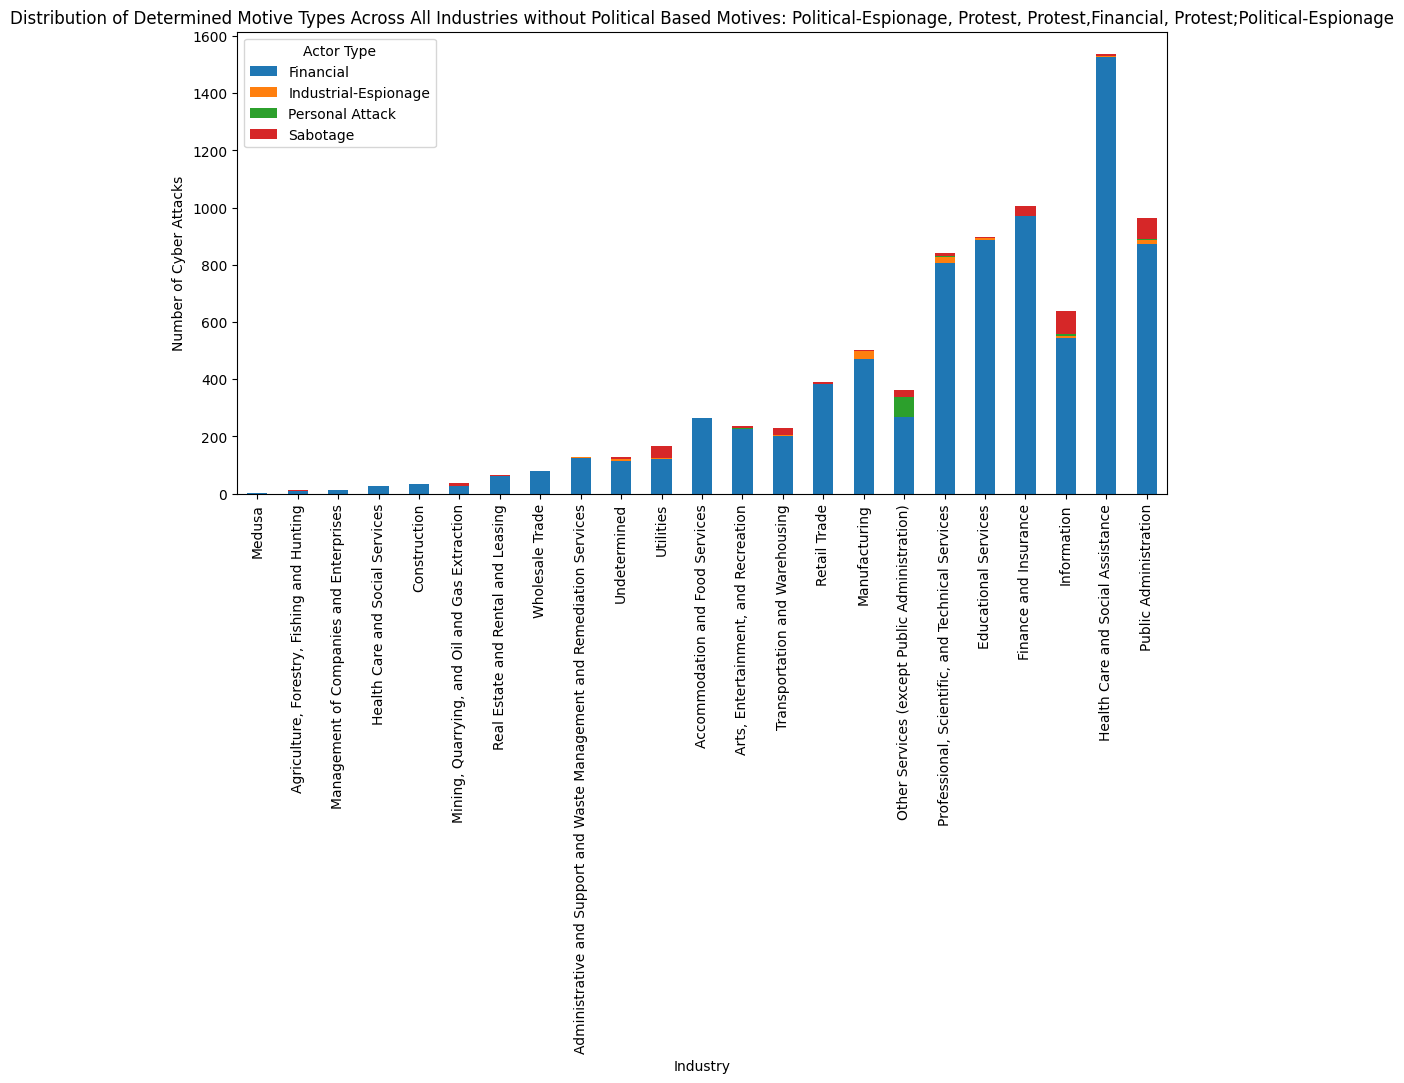

In [ ]:
dfMotive[['Financial'	,'Industrial-Espionage'	,'Personal Attack','Sabotage']].plot(kind='bar', stacked=True, figsize=(12, 6))
plt.title('Distribution of Determined Motive Types Across All Industries without Political Based Motives: Political-Espionage, Protest, Protest,Financial, Protest;Political-Espionage')
plt.xlabel('Industry')
plt.ylabel('Number of Cyber Attacks')
plt.xticks(range(len(dfActorType)), dfActorType['Sector Title'], rotation=90)
_ = plt.legend(title='Actor Type')

In [ ]:
#1. Criminal actors in public administration


In [ ]:
public_admin_criminal = dfActorType[dfActorType['Sector Title'] == 'Public Administration']

In [ ]:
public_admin_criminal

actor_type,Sector Title,Criminal,Hacktivist,Hacktvist,Hobbyist,Nation-State,Terrorist,Undetermined,industry_counts
16,Public Administration,1461,830,8,24,252,8,65,2648


In [ ]:
import pandas as pd
import plotly.express as px

# Create a DataFrame for the pie chart
data = {
    'Threat Actor': ['Criminal', 'Hacktivist', 'Hacktvist', 'Hobbyist', 'Nation-State', 'Terrorist', 'Undetermined'],
    'Count': [public_admin_criminal['Criminal'].iloc[0],
              public_admin_criminal['Hacktivist'].iloc[0],
              public_admin_criminal['Hacktvist'].iloc[0],
              public_admin_criminal['Hobbyist'].iloc[0],
              public_admin_criminal['Nation-State'].iloc[0],
              public_admin_criminal['Terrorist'].iloc[0],
              public_admin_criminal['Undetermined'].iloc[0]]
}
df_pie = pd.DataFrame(data)

# Create the pie chart
fig = px.pie(df_pie, values='Count', names='Threat Actor', title='Threat Actors in Public Administration')
fig.show()


In [ ]:
import pandas as pd
import plotly.express as px

# Create a DataFrame for the pie chart
data = {
    'Threat Actor': ['Criminal', 'Hacktivist', 'Hacktvist', 'Hobbyist', 'Nation-State', 'Terrorist'],
    'Count': [public_admin_criminal['Criminal'].iloc[0],
              public_admin_criminal['Hacktivist'].iloc[0],
              public_admin_criminal['Hacktvist'].iloc[0],
              public_admin_criminal['Hobbyist'].iloc[0],
              public_admin_criminal['Nation-State'].iloc[0],
              public_admin_criminal['Terrorist'].iloc[0]]
}
df_pie = pd.DataFrame(data)

# Create the pie chart
fig = px.pie(df_pie, values='Count', names='Threat Actor', title='Determined Threat Actors in Public Administration')
fig.show()


In [ ]:
# 2. Criminal actors in healthcare and social assistance

In [ ]:
public_admin_motive = dfMotive[dfActorType['Sector Title'] == 'Public Administration']

In [ ]:
import pandas as pd
import plotly.express as px

# Create a DataFrame for the pie chart
data = {
    'Threat Actor': ['Financial',
 'Industrial-Espionage',
 'Personal Attack',
 'Political-Espionage',
 'Protest',
 'Protest,Financial',
 'Protest;Political-Espionage',
 'Sabotage',
 'Undetermined Motive'],
    'Count': [public_admin_motive['Financial'].iloc[0],
              public_admin_motive['Industrial-Espionage'].iloc[0],
              public_admin_motive['Personal Attack'].iloc[0],
              public_admin_motive['Political-Espionage'].iloc[0],
              public_admin_motive['Protest'].iloc[0],
              public_admin_motive['Protest,Financial'].iloc[0],
              public_admin_motive['Protest;Political-Espionage'].iloc[0],
              public_admin_motive['Sabotage'].iloc[0],
              public_admin_motive['Undetermined Motive'].iloc[0]]
}
df_pie = pd.DataFrame(data)

# Create the pie chart
fig = px.pie(df_pie, values='Count', names='Threat Actor', title='Motives of Attacks on Public Administration')
fig.show()


In [ ]:
import pandas as pd
import plotly.express as px

# Create a DataFrame for the pie chart
data = {
    'Threat Actor': ['Financial',
 'Industrial-Espionage',
 'Personal Attack',
 'Political-Espionage',
 'Protest',
 'Protest,Financial',
 'Protest;Political-Espionage',
 'Sabotage'],
    'Count': [public_admin_motive['Financial'].iloc[0],
              public_admin_motive['Industrial-Espionage'].iloc[0],
              public_admin_motive['Personal Attack'].iloc[0],
              public_admin_motive['Political-Espionage'].iloc[0],
              public_admin_motive['Protest'].iloc[0],
              public_admin_motive['Protest,Financial'].iloc[0],
              public_admin_motive['Protest;Political-Espionage'].iloc[0],
              public_admin_motive['Sabotage'].iloc[0]]
}
df_pie = pd.DataFrame(data)

# Create the pie chart
fig = px.pie(df_pie, values='Count', names='Threat Actor', title='Determined Motives of Attacks on Public Administration')
fig.show()


In [ ]:
healthcareCriminal = dfActorType[dfActorType['Sector Title'] == 'Health Care and Social Assistance']

In [ ]:
import pandas as pd
import plotly.express as px

# Create a DataFrame for the pie chart
data = {
    'Threat Actor': ['Criminal', 'Hacktivist', 'Hacktvist', 'Hobbyist', 'Nation-State', 'Terrorist', 'Undetermined'],
    'Count': [healthcareCriminal['Criminal'].iloc[0],
              healthcareCriminal['Hacktivist'].iloc[0],
              healthcareCriminal['Hacktvist'].iloc[0],
              healthcareCriminal['Hobbyist'].iloc[0],
              healthcareCriminal['Nation-State'].iloc[0],
              healthcareCriminal['Terrorist'].iloc[0],
              healthcareCriminal['Undetermined'].iloc[0]]
}
df_pie = pd.DataFrame(data)

# Create the pie chart
fig = px.pie(df_pie, values='Count', names='Threat Actor', title='Threat Actors in Health Care and Social Assistance')
fig.show()


In [ ]:
import pandas as pd
import plotly.express as px

# Create a DataFrame for the pie chart
data = {
    'Threat Actor': ['Criminal', 'Hacktivist', 'Hacktvist', 'Hobbyist', 'Nation-State', 'Terrorist'],
    'Count': [healthcareCriminal['Criminal'].iloc[0],
              healthcareCriminal['Hacktivist'].iloc[0],
              healthcareCriminal['Hacktvist'].iloc[0],
              healthcareCriminal['Hobbyist'].iloc[0],
              healthcareCriminal['Nation-State'].iloc[0],
              healthcareCriminal['Terrorist'].iloc[0]]
}
df_pie = pd.DataFrame(data)

# Create the pie chart
fig = px.pie(df_pie, values='Count', names='Threat Actor', title='Determined Threat Actors in Health Care and Social Assistance')
fig.show()


In [ ]:
healthcareMotive = dfMotive[dfActorType['Sector Title'] == 'Health Care and Social Assistance']

In [ ]:
import pandas as pd
import plotly.express as px

# Create a DataFrame for the pie chart
data = {
    'Threat Actor': ['Financial',
 'Industrial-Espionage',
 'Personal Attack',
 'Political-Espionage',
 'Protest',
 'Protest,Financial',
 'Protest;Political-Espionage',
 'Sabotage',
 'Undetermined Motive'],
    'Count': [healthcareMotive['Financial'].iloc[0],
              healthcareMotive['Industrial-Espionage'].iloc[0],
              healthcareMotive['Personal Attack'].iloc[0],
              healthcareMotive['Political-Espionage'].iloc[0],
              healthcareMotive['Protest'].iloc[0],
              healthcareMotive['Protest,Financial'].iloc[0],
              healthcareMotive['Protest;Political-Espionage'].iloc[0],
              healthcareMotive['Sabotage'].iloc[0],
              healthcareMotive['Undetermined Motive'].iloc[0]]
}
df_pie = pd.DataFrame(data)

# Create the pie chart
fig = px.pie(df_pie, values='Count', names='Threat Actor', title='Motives of Attacks on Health Care and Social Assistance')
fig.show()


In [ ]:
import pandas as pd
import plotly.express as px

# Create a DataFrame for the pie chart
data = {
    'Threat Actor': ['Financial',
 'Industrial-Espionage',
 'Personal Attack',
 'Political-Espionage',
 'Protest',
 'Protest,Financial',
 'Protest;Political-Espionage',
 'Sabotage'],
    'Count': [healthcareMotive['Financial'].iloc[0],
              healthcareMotive['Industrial-Espionage'].iloc[0],
              healthcareMotive['Personal Attack'].iloc[0],
              healthcareMotive['Political-Espionage'].iloc[0],
              healthcareMotive['Protest'].iloc[0],
              healthcareMotive['Protest,Financial'].iloc[0],
              healthcareMotive['Protest;Political-Espionage'].iloc[0],
              healthcareMotive['Sabotage'].iloc[0]]
}
df_pie = pd.DataFrame(data)

# Create the pie chart
fig = px.pie(df_pie, values='Count', names='Threat Actor', title='Determined Motives of Attacks on Health Care and Social Assistance')
fig.show()


In [ ]:
infoCriminal = dfActorType[dfActorType['Sector Title'] == 'Information']

In [ ]:
infoCriminal

actor_type,Sector Title,Criminal,Hacktivist,Hacktvist,Hobbyist,Nation-State,Terrorist,Undetermined,industry_counts
9,Information,978,213,1,29,122,14,84,1441


In [ ]:
import pandas as pd
import plotly.express as px

# Create a DataFrame for the pie chart
data = {
    'Threat Actor': ['Criminal', 'Hacktivist', 'Hacktvist', 'Hobbyist', 'Nation-State', 'Terrorist', 'Undetermined'],
    'Count': [infoCriminal['Criminal'].iloc[0],
              infoCriminal['Hacktivist'].iloc[0],
              infoCriminal['Hacktvist'].iloc[0],
              infoCriminal['Hobbyist'].iloc[0],
              infoCriminal['Nation-State'].iloc[0],
              infoCriminal['Terrorist'].iloc[0],
              infoCriminal['Undetermined'].iloc[0]]
}
df_pie = pd.DataFrame(data)

# Create the pie chart
fig = px.pie(df_pie, values='Count', names='Threat Actor', title='Threat Actors in Information')
fig.show()


In [ ]:
import pandas as pd
import plotly.express as px

# Create a DataFrame for the pie chart
data = {
    'Threat Actor': ['Criminal', 'Hacktivist', 'Hacktvist', 'Hobbyist', 'Nation-State', 'Terrorist'],
    'Count': [infoCriminal['Criminal'].iloc[0],
              infoCriminal['Hacktivist'].iloc[0],
              infoCriminal['Hacktvist'].iloc[0],
              infoCriminal['Hobbyist'].iloc[0],
              infoCriminal['Nation-State'].iloc[0],
              infoCriminal['Terrorist'].iloc[0]]
}
df_pie = pd.DataFrame(data)

# Create the pie chart
fig = px.pie(df_pie, values='Count', names='Threat Actor', title='Determined Threat Actors in Information')
fig.show()


In [ ]:
infoMotive = dfMotive[dfActorType['Sector Title'] == 'Information']

In [ ]:
import pandas as pd
import plotly.express as px

# Create a DataFrame for the pie chart
data = {
    'Threat Actor': ['Financial',
 'Industrial-Espionage',
 'Personal Attack',
 'Political-Espionage',
 'Protest',
 'Protest,Financial',
 'Protest;Political-Espionage',
 'Sabotage',
 'Undetermined Motive'],
    'Count': [infoMotive['Financial'].iloc[0],
              infoMotive['Industrial-Espionage'].iloc[0],
              infoMotive['Personal Attack'].iloc[0],
              infoMotive['Political-Espionage'].iloc[0],
              infoMotive['Protest'].iloc[0],
              infoMotive['Protest,Financial'].iloc[0],
              infoMotive['Protest;Political-Espionage'].iloc[0],
              infoMotive['Sabotage'].iloc[0],
              infoMotive['Undetermined Motive'].iloc[0]]
}
df_pie = pd.DataFrame(data)

# Create the pie chart
fig = px.pie(df_pie, values='Count', names='Threat Actor', title='Motives of Attacks on Information')
fig.show()


In [ ]:
import pandas as pd
import plotly.express as px

# Create a DataFrame for the pie chart
data = {
    'Threat Actor': ['Financial',
 'Industrial-Espionage',
 'Personal Attack',
 'Political-Espionage',
 'Protest',
 'Protest,Financial',
 'Protest;Political-Espionage',
 'Sabotage'],
    'Count': [infoMotive['Financial'].iloc[0],
              infoMotive['Industrial-Espionage'].iloc[0],
              infoMotive['Personal Attack'].iloc[0],
              infoMotive['Political-Espionage'].iloc[0],
              infoMotive['Protest'].iloc[0],
              infoMotive['Protest,Financial'].iloc[0],
              infoMotive['Protest;Political-Espionage'].iloc[0],
              infoMotive['Sabotage'].iloc[0]]
}
df_pie = pd.DataFrame(data)

# Create the pie chart
fig = px.pie(df_pie, values='Count', names='Threat Actor', title='Determined Motives of Attacks on Information')
fig.show()


In [ ]:
### exploitative disruptive

In [ ]:
typeMotiveDf = df.groupby('event_type')['motive'].value_counts().unstack(fill_value=0).reset_index()

In [ ]:
typeActorDf = df.groupby('event_type')['actor_type'].value_counts().unstack(fill_value=0).reset_index()

In [ ]:
typeActorDf

actor_type,event_type,Criminal,Hacktivist,Hacktvist,Hobbyist,Nation-State,Terrorist,Undetermined
0,Disruptive,2470,1389,8,139,256,5,93
1,Exploitive,5671,439,8,48,507,25,302
2,Mixed,2369,72,1,4,35,0,19
3,Undetermined,166,9,0,0,5,0,1


In [ ]:
disruptiveMotiveDf =  typeMotiveDf[typeMotiveDf['event_type'] == 'Disruptive']

In [ ]:








disruptiveMotiveDf

motive,event_type,Financial,Industrial-Espionage,Personal Attack,Political-Espionage,Protest,"Protest,Financial",Protest;Political-Espionage,Sabotage,Undetermined
0,Disruptive,1498,0,27,9,1269,0,0,274,1283


In [ ]:
import pandas as pd
import plotly.express as px

# Create a DataFrame for the pie chart
data = {
    'Threat Actor': ['Financial',
 'Industrial-Espionage',
 'Personal Attack',
 'Political-Espionage',
 'Protest',
 'Protest,Financial',
 'Protest;Political-Espionage',
 'Sabotage'],
    'Count': [disruptiveMotiveDf['Financial'].iloc[0],
              disruptiveMotiveDf['Industrial-Espionage'].iloc[0],
              disruptiveMotiveDf['Personal Attack'].iloc[0],
              disruptiveMotiveDf['Political-Espionage'].iloc[0],
              disruptiveMotiveDf['Protest'].iloc[0],
              disruptiveMotiveDf['Protest,Financial'].iloc[0],
              disruptiveMotiveDf['Protest;Political-Espionage'].iloc[0],
              disruptiveMotiveDf['Sabotage'].iloc[0]]
}
df_pie = pd.DataFrame(data)

# Create the pie chart
fig = px.pie(df_pie, values='Count', names='Threat Actor', title='Determined Motives of Disruptive Attacks')
fig.show()


In [ ]:
exploitiveMotiveDf =  typeMotiveDf[typeMotiveDf['event_type'] == 'Exploitive']

In [ ]:
import pandas as pd
import plotly.express as px

# Create a DataFrame for the pie chart
data = {
    'Threat Actor': ['Financial',
 'Industrial-Espionage',
 'Personal Attack',
 'Political-Espionage',
 'Protest',
 'Protest,Financial',
 'Protest;Political-Espionage',
 'Sabotage'],
    'Count': [exploitiveMotiveDf['Financial'].iloc[0],
              exploitiveMotiveDf['Industrial-Espionage'].iloc[0],
              exploitiveMotiveDf['Personal Attack'].iloc[0],
              exploitiveMotiveDf['Political-Espionage'].iloc[0],
              exploitiveMotiveDf['Protest'].iloc[0],
              exploitiveMotiveDf['Protest,Financial'].iloc[0],
              exploitiveMotiveDf['Protest;Political-Espionage'].iloc[0],
              exploitiveMotiveDf['Sabotage'].iloc[0]]
}
df_pie = pd.DataFrame(data)

# Create the pie chart
fig = px.pie(df_pie, values='Count', names='Threat Actor', title='Determined Motives of Exploitive Attacks')
fig.show()


In [ ]:
exploitiveActorDf =  typeActorDf[typeActorDf['event_type'] == 'Exploitive']

In [ ]:
import pandas as pd
import plotly.express as px

# Create a DataFrame for the pie chart
data = {
    'Threat Actor': ['Criminal', 'Hacktivist', 'Hacktvist', 'Hobbyist', 'Nation-State', 'Terrorist'],
    'Count': [exploitiveActorDf['Criminal'].iloc[0],
              exploitiveActorDf['Hacktivist'].iloc[0],
              exploitiveActorDf['Hacktvist'].iloc[0],
              exploitiveActorDf['Hobbyist'].iloc[0],
              exploitiveActorDf['Nation-State'].iloc[0],
              exploitiveActorDf['Terrorist'].iloc[0]]
}
df_pie = pd.DataFrame(data)

# Create the pie chart
fig = px.pie(df_pie, values='Count', names='Threat Actor', title='Determined Threat Actors of Exploitive Attacks')
fig.show()


In [ ]:
disruptiveActorDf = typeActorDf[typeActorDf['event_type'] == 'Disruptive']

In [ ]:
import pandas as pd
import plotly.express as px

# Create a DataFrame for the pie chart
data = {
    'Threat Actor': ['Criminal', 'Hacktivist', 'Hacktvist', 'Hobbyist', 'Nation-State', 'Terrorist'],
    'Count': [disruptiveActorDf['Criminal'].iloc[0],
              disruptiveActorDf['Hacktivist'].iloc[0],
              disruptiveActorDf['Hacktvist'].iloc[0],
              disruptiveActorDf['Hobbyist'].iloc[0],
              disruptiveActorDf['Nation-State'].iloc[0],
              disruptiveActorDf['Terrorist'].iloc[0]]
}
df_pie = pd.DataFrame(data)

# Create the pie chart
fig = px.pie(df_pie, values='Count', names='Threat Actor', title='Determined Threat Actors of Disruptive Attacks')
fig.show()


In [ ]:
disruptiveActorDf

actor_type,event_type,Criminal,Hacktivist,Hacktvist,Hobbyist,Nation-State,Terrorist,Undetermined
0,Disruptive,2470,1389,8,139,256,5,93


# Country

In [58]:
actorStateCts = df.groupby('actor_country').size().reset_index(name='counts')
actorStateCts.sort_values(by='counts', ascending=False, inplace=True)
actorStateCts

,actor_country,counts
74,Undetermined,10597
60,Russian Federation,1847
16,China,171
38,Korea (the Democratic People's Republic of),160
77,United States of America,142
...,...,...
66,Sri Lanka,1
55,Peru,1
63,Sierra Leone,1
25,Ghana,1


In [59]:
affectedCts = df.groupby('country').size().reset_index(name='counts')
affectedCts.sort_values(by='counts', ascending=False, inplace=True)
affectedCts

,country,counts
160,United States of America,6779
159,United Kingdom of Great Britain and Northern I...,756
70,Italy,413
156,Ukraine,407
125,Russian Federation,389
...,...,...
115,Papua New Guinea,1
67,Islamic Republic of Iran,1
32,Cuba,1
146,Tajikistan,1


In [65]:
## poverty and inequality indicators
# pip.csv from https://pip.worldbank.org/poverty-calculator

In [67]:
pipDf = pd.read_csv('Categorizing-Cyber-Attacks/draft/data/pip_worldbank.csv', encoding='latin-1')

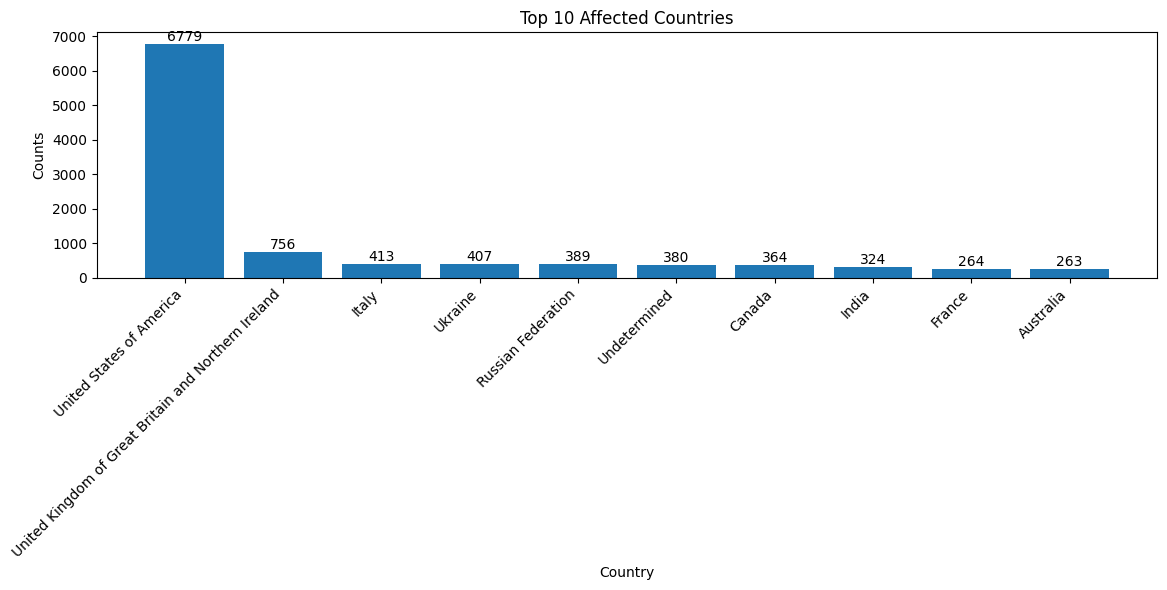

In [68]:
import matplotlib.pyplot as plt

top_10_countries = affectedCts.head(10)

plt.figure(figsize=(12, 6))
bars = plt.bar(top_10_countries['country'], top_10_countries['counts'])
plt.xlabel('Country')
plt.ylabel('Counts')
plt.title('Top 10 Affected Countries')
plt.xticks(rotation=45, ha='right')

for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval, int(yval), va='bottom', ha='center')

plt.tight_layout()
plt.show()

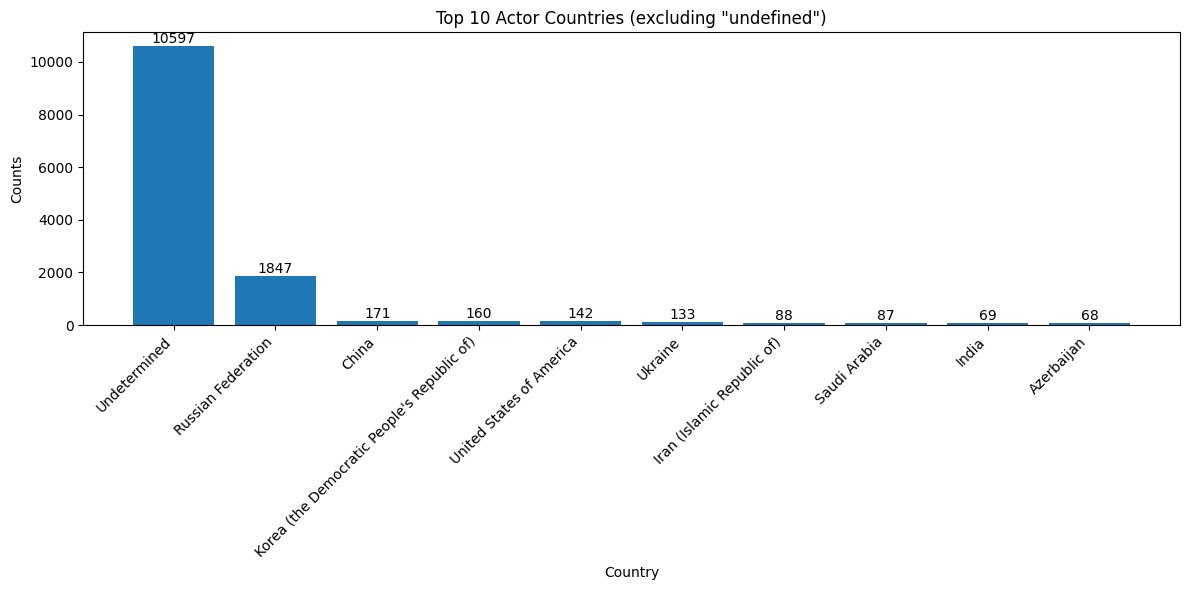

In [69]:
import matplotlib.pyplot as plt

actorStateCts_filtered = actorStateCts[actorStateCts['actor_country'] != 'undefined']

top_10_countries = actorStateCts_filtered.sort_values(by='counts', ascending=False).head(10)

plt.figure(figsize=(12, 6))
bars = plt.bar(top_10_countries['actor_country'], top_10_countries['counts'])
plt.xlabel('Country')
plt.ylabel('Counts')
plt.title('Top 10 Actor Countries (excluding "undefined")')
plt.xticks(rotation=45, ha='right')

for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval, int(yval), va='bottom', ha='center')

plt.tight_layout()
plt.show()

In [70]:
pipDf.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2456 entries, 0 to 2455
Data columns (total 44 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   region_name           2456 non-null   object 
 1   region_code           2456 non-null   object 
 2   country_name          2456 non-null   object 
 3   country_code          2456 non-null   object 
 4   reporting_year        2456 non-null   int64  
 5   reporting_level       2456 non-null   object 
 6   survey_acronym        2456 non-null   object 
 7   survey_coverage       2456 non-null   object 
 8   survey_year           2456 non-null   float64
 9   welfare_type          2456 non-null   object 
 10  survey_comparability  2456 non-null   int64  
 11  comparable_spell      2456 non-null   object 
 12  poverty_line          2456 non-null   float64
 13  headcount             2456 non-null   float64
 14  poverty_gap           2456 non-null   float64
 15  poverty_severity     

In [71]:
pipDf

,region_name,region_code,country_name,country_code,reporting_year,reporting_level,survey_acronym,survey_coverage,survey_year,welfare_type,...,reporting_pop,reporting_gdp,reporting_pce,is_interpolated,distribution_type,estimation_type,spl,spr,pg,estimate_type
0,Sub-Saharan Africa,SSA,Angola,AGO,2000,national,HBS,national,2000.21,consumption,...,16509042.25,1909.502065,NaN,False,micro,survey,3.486659,0.372371,9.722334,NaN
1,Sub-Saharan Africa,SSA,Angola,AGO,2008,national,IBEP-MICS,national,2008.50,consumption,...,22099598.00,3176.672166,1201.311092,False,micro,survey,3.501550,0.353722,6.925334,NaN
2,Sub-Saharan Africa,SSA,Angola,AGO,2018,national,IDREA,national,2018.17,consumption,...,31457142.35,2777.843045,1495.340595,False,micro,survey,2.860251,0.422226,11.098810,NaN
3,Europe & Central Asia,ECA,Albania,ALB,1996,national,EWS,national,1996.00,consumption,...,3168033.00,1633.552000,1716.336801,False,micro,survey,4.636051,0.195180,3.999503,NaN
4,Europe & Central Asia,ECA,Albania,ALB,2002,national,LSMS,national,2002.00,consumption,...,3051010.00,2247.498080,1685.203078,False,micro,survey,4.494071,0.212854,4.208419,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2451,Sub-Saharan Africa,SSA,Zambia,ZMB,2015,national,LCMS-VII,national,2015.00,consumption,...,16248230.00,1307.909649,662.412898,False,micro,survey,2.150000,0.607931,23.087937,NaN
2452,Sub-Saharan Africa,SSA,Zambia,ZMB,2022,national,LCMS-VIII,national,2022.00,consumption,...,20017675.00,1308.101838,NaN,False,imputed,survey,2.150000,0.643497,23.058921,NaN
2453,Sub-Saharan Africa,SSA,Zimbabwe,ZWE,2011,national,ICES,national,2011.00,consumption,...,13025785.00,1239.241793,967.844700,False,group,survey,3.049416,0.383260,7.863172,NaN
2454,Sub-Saharan Africa,SSA,Zimbabwe,ZWE,2017,national,PICES,national,2017.00,consumption,...,14751101.00,1421.240769,1099.361086,False,micro,survey,2.587279,0.440398,9.875030,NaN


# Potential Regression Analyses

Predicting Event Frequency over time:
we can use year and month as predictors to do the model. Linear regression. How has the number of cybersecuirty incidents changed over time?

Impact of Actor Type on event subtypes. We will use actor_type as a categorical variable to predict event subtype. Logistic Regression. Are certain actor types more likely to perform specific types of events

Using country and motive to predict event frequency or the likelihood of a specific event type. Linear Regression. Does the country or motive significantly influence the number of incidents?

In [72]:
import matplotlib as plt
import seaborn as sns

In [74]:
df = original_df

In [75]:
df.head()

,slug,event_date,year,month,actor,actor_type,organization,industry_code,industry,motive,event_type,event_subtype,description,source_url,country,actor_country,change_log
0,1f72c2eb8ab303e4,2014-01-01,2014,1,Undetermined,Criminal,Barry University,61,Educational Services,Undetermined,Exploitive,Exploitation of End Hosts,Barry University notifies patients of its Foot...,https://www.beckershospitalreview.com/healthca...,United States of America,Undetermined,NaN
1,ecac8b3e60a2f72f,2014-01-01,2014,1,Undetermined,Criminal,Record Assist LLC,54,"Professional, Scientific, and Technical Services",Undetermined,Exploitive,Exploitation of Application Server,Record Assist LLC notifies of an unauthorized ...,https://privacyrights.org/data-breaches/record...,United States of America,Undetermined,NaN
2,3bbe0695e2d019f3,2014-01-01,2014,1,Syrian Electronic Army,Hacktivist,Skype's Social Media,54,"Professional, Scientific, and Technical Services",Protest,Disruptive,Message Manipulation,The Syrian Electronic Army hacks Skype's Twitt...,http://thenextweb.com/microsoft/2014/01/01/sky...,United States of America,Syrian Arab Republic,NaN
3,6100014f6ca84b3d,2014-01-02,2014,1,Undetermined,Criminal,Snapchat,51,Information,Undetermined,Exploitive,Exploitation of Application Server,Greyhat hackers publish the partial phone numb...,http://arstechnica.com/security/2014/01/greyha...,United States of America,Undetermined,NaN
4,3a94b8cf6dde1f66,2014-01-03,2014,1,DERP Trolling,Undetermined,Battle.net,51,Information,Undetermined,Disruptive,External Denial of Service,"The servers for Steam, Origin, Battle.net, and...",http://arstechnica.com/gaming/2014/01/multiple...,United States of America,Undetermined,NaN


In [76]:
df['event_date'] = pd.to_datetime(df['event_date'], format = 'mixed')


In [77]:
df.head()

,slug,event_date,year,month,actor,actor_type,organization,industry_code,industry,motive,event_type,event_subtype,description,source_url,country,actor_country,change_log
0,1f72c2eb8ab303e4,2014-01-01,2014,1,Undetermined,Criminal,Barry University,61,Educational Services,Undetermined,Exploitive,Exploitation of End Hosts,Barry University notifies patients of its Foot...,https://www.beckershospitalreview.com/healthca...,United States of America,Undetermined,NaN
1,ecac8b3e60a2f72f,2014-01-01,2014,1,Undetermined,Criminal,Record Assist LLC,54,"Professional, Scientific, and Technical Services",Undetermined,Exploitive,Exploitation of Application Server,Record Assist LLC notifies of an unauthorized ...,https://privacyrights.org/data-breaches/record...,United States of America,Undetermined,NaN
2,3bbe0695e2d019f3,2014-01-01,2014,1,Syrian Electronic Army,Hacktivist,Skype's Social Media,54,"Professional, Scientific, and Technical Services",Protest,Disruptive,Message Manipulation,The Syrian Electronic Army hacks Skype's Twitt...,http://thenextweb.com/microsoft/2014/01/01/sky...,United States of America,Syrian Arab Republic,NaN
3,6100014f6ca84b3d,2014-01-02,2014,1,Undetermined,Criminal,Snapchat,51,Information,Undetermined,Exploitive,Exploitation of Application Server,Greyhat hackers publish the partial phone numb...,http://arstechnica.com/security/2014/01/greyha...,United States of America,Undetermined,NaN
4,3a94b8cf6dde1f66,2014-01-03,2014,1,DERP Trolling,Undetermined,Battle.net,51,Information,Undetermined,Disruptive,External Denial of Service,"The servers for Steam, Origin, Battle.net, and...",http://arstechnica.com/gaming/2014/01/multiple...,United States of America,Undetermined,NaN


In [78]:
event_frequency = df.groupby(df['event_date'].dt.to_period('M')).size().reset_index(name='event_count')

In [79]:
event_frequency['event_date'] = event_frequency['event_date'].dt.to_timestamp()

In [80]:
event_frequency.head()

,event_date,event_count
0,2014-01-01,85
1,2014-02-01,83
2,2014-03-01,40
3,2014-04-01,54
4,2014-05-01,40


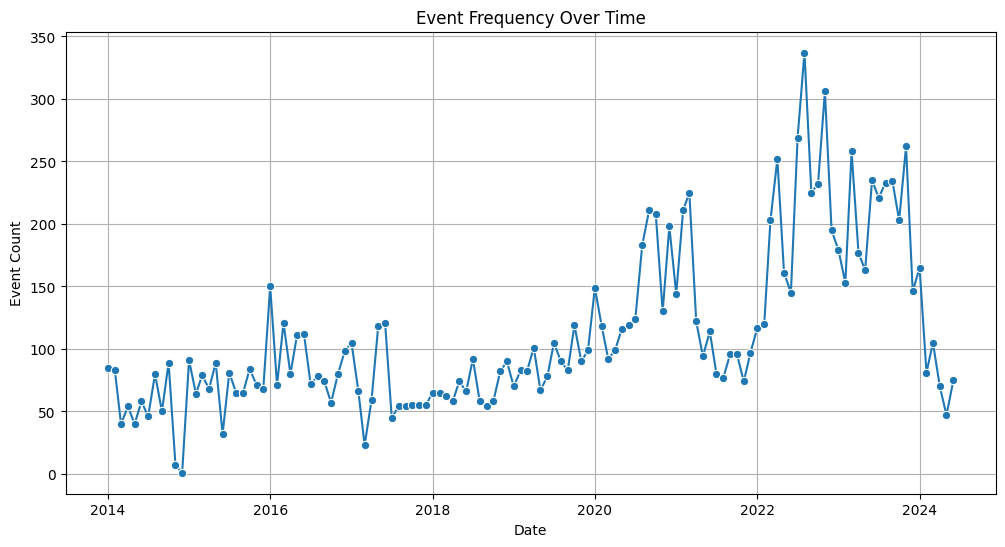

In [81]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(12,6))
sns.lineplot(data = event_frequency,x='event_date',y='event_count',marker='o')
plt.title('Event Frequency Over Time')
plt.xlabel('Date')
plt.ylabel('Event Count')
plt.grid(True)
plt.show()

In [82]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error,r2_score
import numpy as np

In [83]:
event_frequency['timestamp'] = event_frequency['event_date'].map(lambda x:x.toordinal())
X = event_frequency[['timestamp']]
y = event_frequency['event_count']

In [84]:
X

,timestamp
0,735234
1,735265
2,735293
3,735324
4,735354
...,...
121,738917
122,738946
123,738977
124,739007


In [85]:
y

,event_count
0,85
1,83
2,40
3,54
4,40
...,...
121,81
122,105
123,70
124,47


In [86]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [87]:
model = LinearRegression()
model.fit(X_train,y_train)

LinearRegression()

In [88]:
y_pred = model.predict(X_test)

In [89]:
mse = mean_squared_error(y_test,y_pred)
r2 = r2_score(y_test,y_pred)

In [90]:
model_coefficients = model.coef_
model_intercept = model.intercept_

In [91]:
mse

1595.649653656625

In [92]:
r2

0.4893389295586388

In [93]:
model_coefficients

array([0.03703215])

In [94]:
model_intercept

-27184.285908586462

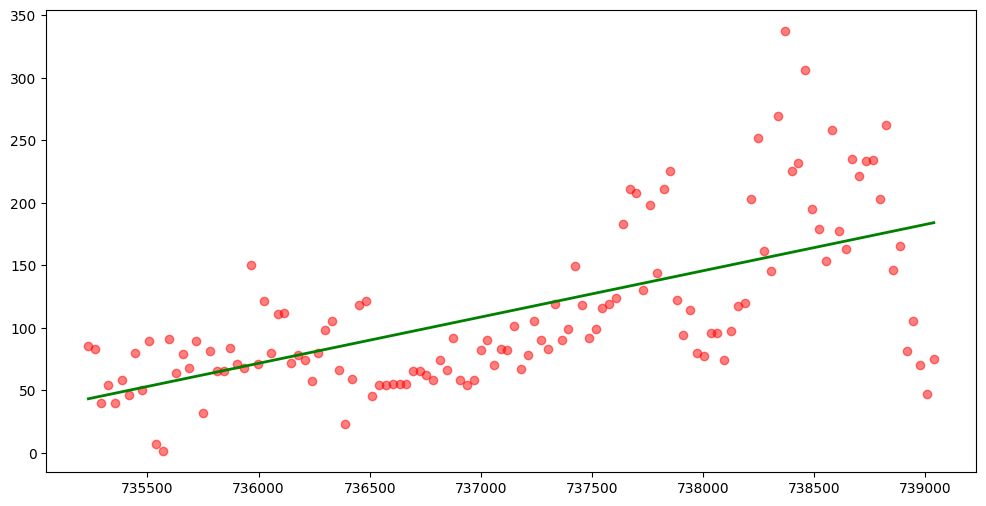

In [95]:
plt.figure(figsize=(12,6))
plt.scatter(event_frequency['timestamp'],event_frequency['event_count'],color='red',alpha=0.5,label='Actual Data')
regression_line = model.predict(event_frequency[['timestamp']])
plt.plot(event_frequency['timestamp'],regression_line,color='green',linewidth=2,label='Regression Line')

In [96]:
df['actor_type'].unique()

array(['Criminal', 'Hacktivist', 'Undetermined', 'Hobbyist',
       'Nation-State', 'Terrorist', 'Hacktvist'], dtype=object)

In [97]:
df['actor_type'] = df['actor_type'].replace('Hacktvist','Hacktivist')
df['actor_type'].unique()

array(['Criminal', 'Hacktivist', 'Undetermined', 'Hobbyist',
       'Nation-State', 'Terrorist'], dtype=object)

In [98]:
df_encoded = pd.get_dummies(df,columns=['actor_type','event_type'],drop_first=True)

In [99]:
df_encoded

,slug,event_date,year,month,actor,organization,industry_code,industry,motive,event_subtype,...,actor_country,change_log,actor_type_Hacktivist,actor_type_Hobbyist,actor_type_Nation-State,actor_type_Terrorist,actor_type_Undetermined,event_type_Exploitive,event_type_Mixed,event_type_Undetermined
0,1f72c2eb8ab303e4,2014-01-01,2014,1,Undetermined,Barry University,61,Educational Services,Undetermined,Exploitation of End Hosts,...,Undetermined,NaN,False,False,False,False,False,True,False,False
1,ecac8b3e60a2f72f,2014-01-01,2014,1,Undetermined,Record Assist LLC,54,"Professional, Scientific, and Technical Services",Undetermined,Exploitation of Application Server,...,Undetermined,NaN,False,False,False,False,False,True,False,False
2,3bbe0695e2d019f3,2014-01-01,2014,1,Syrian Electronic Army,Skype's Social Media,54,"Professional, Scientific, and Technical Services",Protest,Message Manipulation,...,Syrian Arab Republic,NaN,True,False,False,False,False,False,False,False
3,6100014f6ca84b3d,2014-01-02,2014,1,Undetermined,Snapchat,51,Information,Undetermined,Exploitation of Application Server,...,Undetermined,NaN,False,False,False,False,False,True,False,False
4,3a94b8cf6dde1f66,2014-01-03,2014,1,DERP Trolling,Battle.net,51,Information,Undetermined,External Denial of Service,...,Undetermined,NaN,False,False,False,False,True,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14036,9099BBAE1A95E0AD,2024-05-10,2024,5,LockBit 3.0,University of Siena,61,Educational Services,Financial,Data Attack; Exploitation of Application Server,...,Undetermined,NaN,False,False,False,False,False,False,True,False
14037,A81573A2AD4D7527,2024-05-01,2024,5,Black Basta,Atlas,21,"Mining, Quarrying, and Oil and Gas Extraction",Financial,Data Attack; Exploitation of Application Server,...,Russian Federation,NaN,False,False,False,False,False,False,True,False
14038,25D303249D037FE0,2023-05-01,2023,5,Undetermined,Western Sydney University,61,Educational Services,Undetermined,Undetermined,...,Undetermined,*Cyber event detected and/or reported in 2024 ...,False,False,False,False,True,False,False,True
14039,2E80B2C74A7F38A7,2024-05-01,2024,5,Undetermined,At least three Wyndham hotels,72,Accommodation and Food Services,Financial,Exploitation of Application Server,...,Undetermined,NaN,False,False,False,False,False,True,False,False


In [100]:
df_encoded.columns

Index(['slug', 'event_date', 'year', 'month', 'actor', 'organization',
       'industry_code', 'industry', 'motive', 'event_subtype', 'description',
       'source_url', 'country', 'actor_country', 'change_log',
       'actor_type_Hacktivist', 'actor_type_Hobbyist',
       'actor_type_Nation-State', 'actor_type_Terrorist',
       'actor_type_Undetermined', 'event_type_Exploitive', 'event_type_Mixed',
       'event_type_Undetermined'],
      dtype='object')

In [101]:
df_encoded.columns = df_encoded.columns.str.strip()


In [102]:
grouped_data = df_encoded.groupby(df_encoded['event_date'].dt.to_period('M')).agg({
    'event_date': 'first',
    'actor_type_Nation-State': 'sum',
    'actor_type_Hacktivist': 'sum',
    'actor_type_Terrorist': 'sum',
    'actor_type_Undetermined': 'sum',
    'actor_type_Hobbyist': 'sum',
    'event_type_Disruptive':'sum',
    'event_type_Exploitive':'sum',
    'event_type_Mixed':'sum',
    'event_type_Undetermined':'sum',
    'slug':'count'
}).rename(columns={'slug':'event_count'})

KeyError: "Column(s) ['event_type_Disruptive'] do not exist"

In [ ]:
grouped_data.head()

In [103]:
grouped_data.index = grouped_data.index.to_timestamp()
grouped_data['timestamp'] = grouped_data.index.map(lambda x:x.toordinal())

NameError: name 'grouped_data' is not defined

In [ ]:
grouped_data.columns

In [ ]:
X = grouped_data[['timestamp','actor_type_Nation-State','actor_type_Hacktivist','actor_type_Terrorist', 'actor_type_Undetermined',
       'actor_type_Hobbyist', 'event_type_Disruptive', 'event_type_Exploitive',
       'event_type_Mixed', 'event_type_Undetermined']]
y = grouped_data['event_count']

In [ ]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [ ]:
model = LinearRegression()
model.fit(X_train,y_train)

In [ ]:
y_pred = model.predict(X_test)

In [ ]:
mse = mean_squared_error(y_test,y_pred)
r2 = r2_score(y_test,y_pred)

In [ ]:
mse

In [ ]:
r2

In [ ]:
model.coef_

In [ ]:
model.intercept_

## Country and Motive Regression

In [ ]:
df_encoded = pd.get_dummies(df,columns=['country','motive'],drop_first=True)

In [ ]:
df_encoded.columns

In [ ]:
grouped_data = df_encoded.groupby(df_encoded['event_date'].dt.to_period('M')).agg({
    'event_date': 'first',
    'slug': 'count',
    **{col: 'sum' for col in df_encoded.columns if col.startswith('country_')},
    **{col: 'sum' for col in df_encoded.columns if col.startswith('motive_')}
}).rename(columns={'slug': 'event_count'})

In [ ]:
grouped_data.index = grouped_data.index.to_timestamp()

In [ ]:
X = grouped_data.drop(columns=['event_date','event_count'])
y = grouped_data['event_count']

In [ ]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [ ]:
model = LinearRegression()
model.fit(X_train,y_train)

In [ ]:
y_pred = model.predict(X_test)

In [ ]:
mse = mean_squared_error(y_test,y_pred)
r2 = r2_score(y_test,y_pred)

In [ ]:
mse

In [ ]:
r2

In [104]:
model.coef_

array([0.03703215])

In [105]:
model.intercept_

-27184.285908586462

## country and motive prediction

In [106]:
from sklearn.linear_model import LogisticRegression
from sklearn.multioutput import MultiOutputRegressor

In [107]:
df_encoded = pd.get_dummies(df,columns=['country','motive'],drop_first=True)

In [108]:
X = df_encoded.filter(regex='^country_')
y = df_encoded.filter(regex='^motive_')

In [109]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [110]:
logistic_model = MultiOutputRegressor(LogisticRegression(max_iter=1000))
logistic_model.fit(X_train,y_train)

MultiOutputRegressor(estimator=LogisticRegression(max_iter=1000))

In [111]:
y_pred = logistic_model.predict(X_test)

In [112]:
accuracy_scores = (y_pred == y_test.values).mean(axis=0)

In [113]:
accuracy_scores

array([0.99572802, 0.98932004, 0.95407618, 0.89676041, 1.        ,
       1.        , 0.97365611, 0.76931292])

In [114]:
logistic_model.estimators_

[LogisticRegression(max_iter=1000),
 LogisticRegression(max_iter=1000),
 LogisticRegression(max_iter=1000),
 LogisticRegression(max_iter=1000),
 LogisticRegression(max_iter=1000),
 LogisticRegression(max_iter=1000),
 LogisticRegression(max_iter=1000),
 LogisticRegression(max_iter=1000)]

In [115]:
df['motive'].unique()

array(['Undetermined', 'Protest', 'Financial', 'Political-Espionage',
       'Industrial-Espionage', 'Personal Attack', 'Sabotage',
       'Protest,Financial', 'Protest;Political-Espionage'], dtype=object)

In [119]:
pip_data = pd.read_csv('Categorizing-Cyber-Attacks/draft/data/pip_worldbank.csv', encoding='latin-1')
pip_data.head()

,region_name,region_code,country_name,country_code,reporting_year,reporting_level,survey_acronym,survey_coverage,survey_year,welfare_type,...,reporting_pop,reporting_gdp,reporting_pce,is_interpolated,distribution_type,estimation_type,spl,spr,pg,estimate_type
0,Sub-Saharan Africa,SSA,Angola,AGO,2000,national,HBS,national,2000.21,consumption,...,16509042.25,1909.502065,NaN,False,micro,survey,3.486659,0.372371,9.722334,NaN
1,Sub-Saharan Africa,SSA,Angola,AGO,2008,national,IBEP-MICS,national,2008.50,consumption,...,22099598.00,3176.672166,1201.311092,False,micro,survey,3.501550,0.353722,6.925334,NaN
2,Sub-Saharan Africa,SSA,Angola,AGO,2018,national,IDREA,national,2018.17,consumption,...,31457142.35,2777.843045,1495.340595,False,micro,survey,2.860251,0.422226,11.098810,NaN
3,Europe & Central Asia,ECA,Albania,ALB,1996,national,EWS,national,1996.00,consumption,...,3168033.00,1633.552000,1716.336801,False,micro,survey,4.636051,0.195180,3.999503,NaN
4,Europe & Central Asia,ECA,Albania,ALB,2002,national,LSMS,national,2002.00,consumption,...,3051010.00,2247.498080,1685.203078,False,micro,survey,4.494071,0.212854,4.208419,NaN


In [120]:
pip_data['country_name'] = pip_data['country_name'].str.strip()
df['country'] = df['country'].str.strip()

In [121]:
attacks_per_country = df.groupby('country').size().reset_index(name='num_attacks')

In [122]:
attacks_per_country

,country,num_attacks
0,Afghanistan,19
1,Albania,9
2,Algeria,2
3,American Samoa,1
4,Andorra,1
...,...,...
165,Viet Nam,21
166,Vietnam,1
167,Yemen,1
168,Zambia,1


In [123]:
gdp_data = pip_data[['country_name','reporting_gdp']].groupby('country_name').mean().reset_index()

In [124]:
gdp_data

,country_name,reporting_gdp
0,Albania,3727.032490
1,Algeria,3328.657127
2,Angola,2621.339092
3,Argentina,11506.534885
4,Armenia,3048.224191
...,...,...
165,Viet Nam,2125.033402
166,West Bank and Gaza,2818.402252
167,"Yemen, Rep.",2218.190195
168,Zambia,987.870045


In [125]:
merged_data = attacks_per_country.merge(gdp_data,left_on='country',right_on='country_name',how='inner')

In [126]:
merged_data

,country,num_attacks,country_name,reporting_gdp
0,Albania,9,Albania,3727.032490
1,Algeria,2,Algeria,3328.657127
2,Angola,32,Angola,2621.339092
3,Argentina,36,Argentina,11506.534885
4,Armenia,56,Armenia,3048.224191
...,...,...,...,...
110,Uzbekistan,5,Uzbekistan,1739.353116
111,Vanuatu,1,Vanuatu,2793.665067
112,Viet Nam,21,Viet Nam,2125.033402
113,Zambia,1,Zambia,987.870045


In [127]:
merged_data = merged_data.drop(columns=['country_name'])

In [128]:
merged_data

,country,num_attacks,reporting_gdp
0,Albania,9,3727.032490
1,Algeria,2,3328.657127
2,Angola,32,2621.339092
3,Argentina,36,11506.534885
4,Armenia,56,3048.224191
...,...,...,...
110,Uzbekistan,5,1739.353116
111,Vanuatu,1,2793.665067
112,Viet Nam,21,2125.033402
113,Zambia,1,987.870045


In [129]:
from scipy.stats import pearsonr

In [130]:
correlation, p_value = pearsonr(merged_data['num_attacks'],merged_data['reporting_gdp'])
correlation_res = {"Correlation Coefficient":correlation,"p value":p_value}

In [131]:
correlation_res

{'Correlation Coefficient': 0.23266902722100408,
 'p value': 0.012339584314399368}

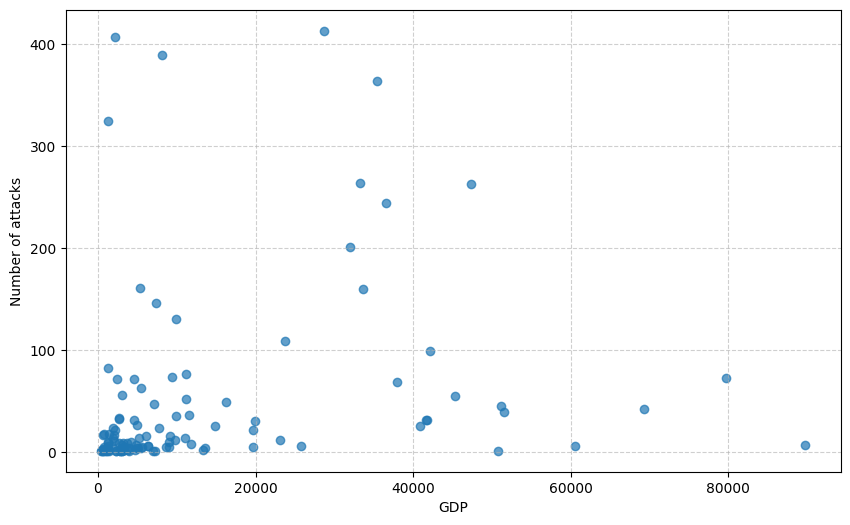

In [132]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
plt.scatter(merged_data['reporting_gdp'],merged_data['num_attacks'],alpha=0.7)
plt.xlabel('GDP')
plt.ylabel('Number of attacks')
plt.grid(True,linestyle='--',alpha=0.6)
plt.show()

In [133]:
import statsmodels.api as sm

In [134]:
X = merged_data['reporting_gdp']
y = merged_data['num_attacks']

In [135]:
X_with_const = sm.add_constant(X)

In [136]:
model = sm.OLS(y,X_with_const).fit()

In [137]:
regression_summary = model.summary()
regression_summary

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:            num_attacks   R-squared:                       0.054
Model:                            OLS   Adj. R-squared:                  0.046
Method:                 Least Squares   F-statistic:                     6.467
Date:                Fri, 14 Feb 2025   Prob (F-statistic):             0.0123
Time:                        15:18:04   Log-Likelihood:                -675.04
No. Observations:                 115   AIC:                             1354.
Df Residuals:                     113   BIC:                             1360.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
=================================================================================
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
const            32.4825      9.977      3.256      0.001      12.717      52.249
reporting_gdp     0.0011      0.000      2.543      0.012       0.000       0.002
==============================================================================
Omnibus:                       86.876   Durbin-Watson:                   2.121
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              440.274
Skew:                           2.782   Prob(JB):                     2.49e-96
Kurtosis:                      10.806   Cond. No.                     2.74e+04
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 2.74e+04. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

In [138]:
from scipy.stats import ttest_ind

In [139]:
median_gdp = merged_data['reporting_gdp'].median()
high_gdp = merged_data[merged_data['reporting_gdp'] > median_gdp]['num_attacks']
low_gdp = merged_data[merged_data['reporting_gdp'] <= median_gdp]['num_attacks']

In [140]:
t_stat,p_value_ttest = ttest_ind(high_gdp,low_gdp,equal_var=False)

In [141]:
t_stat

2.9046807127873153

In [142]:
p_value_ttest

0.004543092013542058

In [143]:
pip_data.columns

Index(['region_name', 'region_code', 'country_name', 'country_code',
       'reporting_year', 'reporting_level', 'survey_acronym',
       'survey_coverage', 'survey_year', 'welfare_type',
       'survey_comparability', 'comparable_spell', 'poverty_line', 'headcount',
       'poverty_gap', 'poverty_severity', 'watts', 'mean', 'median', 'mld',
       'gini', 'polarization', 'decile1', 'decile2', 'decile3', 'decile4',
       'decile5', 'decile6', 'decile7', 'decile8', 'decile9', 'decile10',
       'cpi', 'ppp', 'reporting_pop', 'reporting_gdp', 'reporting_pce',
       'is_interpolated', 'distribution_type', 'estimation_type', 'spl', 'spr',
       'pg', 'estimate_type'],
      dtype='object')

In [144]:
pipData = pip_data[['country_name','reporting_gdp', 'poverty_gap', 'cpi','gini', 'polarization' ]].groupby('country_name').mean().reset_index()

In [145]:
merged2 = attacks_per_country.merge(pipData,left_on='country',right_on='country_name',how='inner')

In [146]:
merged2 = merged2.drop(columns=['country_name'])

In [147]:
merged2

,country,num_attacks,reporting_gdp,poverty_gap,cpi,gini,polarization
0,Albania,9,3727.032490,0.003926,0.906572,0.322512,0.286429
1,Algeria,2,3328.657127,0.005665,0.398037,0.334343,0.282461
2,Angola,32,2621.339092,0.083497,0.516031,0.486414,0.442229
3,Argentina,36,11506.534885,0.011277,10.413204,0.456511,0.435243
4,Armenia,56,3048.224191,0.007133,0.813600,0.321028,0.254472
...,...,...,...,...,...,...,...
110,Uzbekistan,5,1739.353116,0.277617,0.498993,0.359525,0.299395
111,Vanuatu,1,2793.665067,0.029787,0.980569,0.348344,0.295828
112,Viet Nam,21,2125.033402,0.029658,0.664318,0.361377,0.306086
113,Zambia,1,987.870045,0.287399,2.208209,0.519627,0.527839


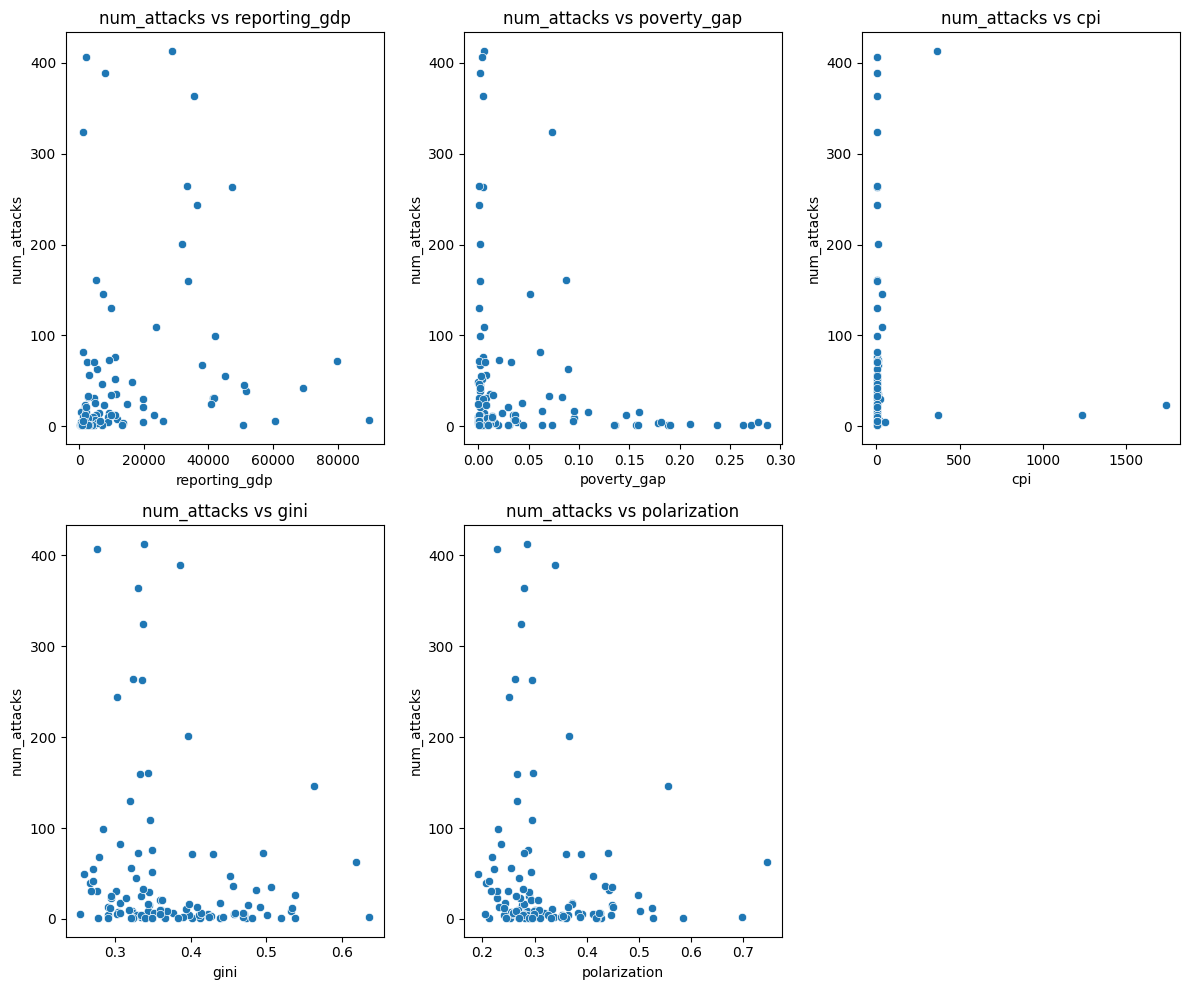

In [148]:
plt.figure(figsize=(12, 10))
independent_vars = ['reporting_gdp', 'poverty_gap', 'cpi', 'gini', 'polarization']
for i, var in enumerate(independent_vars, 1):
    plt.subplot(2, 3, i)
    sns.scatterplot(data=merged2, x=var, y='num_attacks')
    plt.title(f'num_attacks vs {var}')
    plt.xlabel(var)
    plt.ylabel('num_attacks')
plt.tight_layout()
plt.show()


/usr/local/lib/python3.11/dist-packages/pandas/core/arraylike.py:399: RuntimeWarning:

overflow encountered in exp

/usr/local/lib/python3.11/dist-packages/scipy/optimize/_minpack_py.py:1003: RuntimeWarning:

overflow encountered in square

<ipython-input-149-750989267845>:18: OptimizeWarning:

Covariance of the parameters could not be estimated

<ipython-input-149-750989267845>:8: RuntimeWarning:

overflow encountered in exp

/usr/local/lib/python3.11/dist-packages/pandas/core/arraylike.py:399: RuntimeWarning:

overflow encountered in exp

/usr/local/lib/python3.11/dist-packages/scipy/optimize/_minpack_py.py:1003: RuntimeWarning:

overflow encountered in square

<ipython-input-149-750989267845>:18: OptimizeWarning:

Covariance of the parameters could not be estimated

<ipython-input-149-750989267845>:8: RuntimeWarning:

overflow encountered in exp



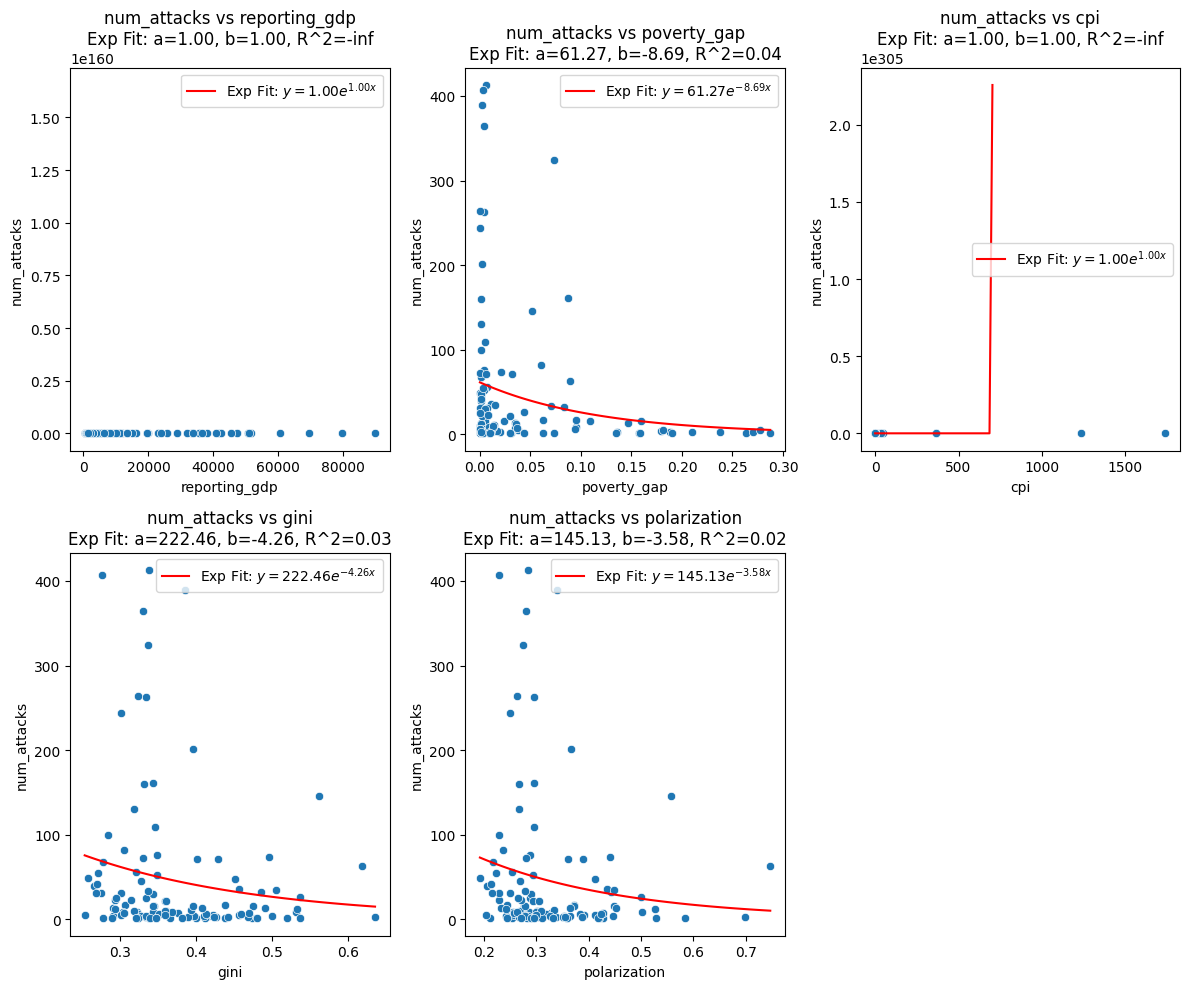

In [149]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.optimize import curve_fit

def exp_func(x, a, b):
    return a * np.exp(b * x)

plt.figure(figsize=(12, 10))

independent_vars = ['reporting_gdp', 'poverty_gap', 'cpi', 'gini', 'polarization']

for i, var in enumerate(independent_vars, 1):
    plt.subplot(2, 3, i)
    sns.scatterplot(data=merged2, x=var, y='num_attacks')

    popt, _ = curve_fit(exp_func, merged2[var], merged2['num_attacks'], maxfev=10000)
    a, b = popt

    x_vals = np.linspace(merged2[var].min(), merged2[var].max(), 100)
    y_vals = exp_func(x_vals, *popt)

    plt.plot(x_vals, y_vals, color='red', label=f'Exp Fit: $y = {a:.2f} e^{{{b:.2f}x}}$')

    predicted_y = exp_func(merged2[var], a, b)
    ss_res = np.sum((merged2['num_attacks'] - predicted_y) ** 2)
    ss_tot = np.sum((merged2['num_attacks'] - np.mean(merged2['num_attacks'])) ** 2)
    r2 = 1 - (ss_res / ss_tot)

    plt.title(f'num_attacks vs {var}\nExp Fit: a={a:.2f}, b={b:.2f}, R^2={r2:.2f}')
    plt.xlabel(var)
    plt.ylabel('num_attacks')
    plt.legend()

plt.tight_layout()
plt.show()


In [150]:
gdp_bins = pd.qcut(merged_data['reporting_gdp'],q=3,labels=['Low GDP','Medium GDP','High GDP'])

In [151]:
merged_data['GDP_Range'] = gdp_bins
gdp_range_comparison = merged_data.groupby('GDP_Range')['num_attacks'].agg(['mean','count','std']).reset_index()

<ipython-input-151-22967807fb7c>:2: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.



In [152]:
gdp_range_comparison

,GDP_Range,mean,count,std
0,Low GDP,30.447368,38,82.534415
1,Medium GDP,30.763158,38,69.836270
2,High GDP,80.205128,39,102.243564


Text(0, 0.5, 'Avg Num Attacks')

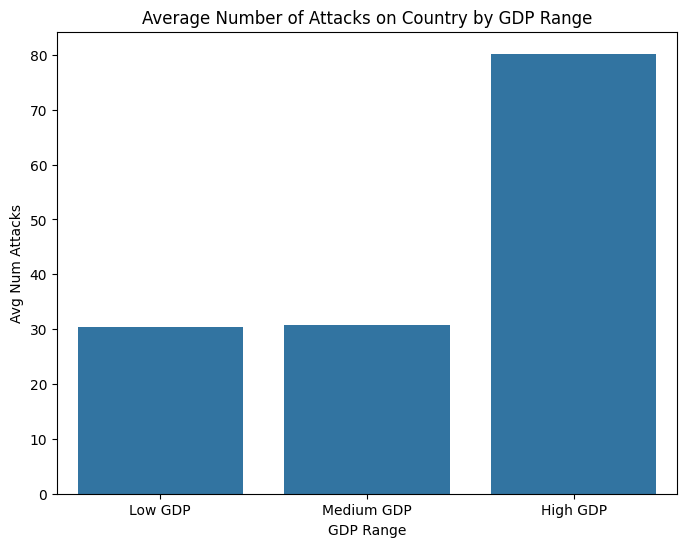

In [153]:

plt.figure(figsize=(8,6))
plt.title("Average Number of Attacks on Country by GDP Range")
sns.barplot(data=gdp_range_comparison,x='GDP_Range',y='mean')
plt.xlabel('GDP Range')
plt.ylabel('Avg Num Attacks')

In [154]:
actor_country_attacks = df.groupby('actor_country').size().reset_index(name='num_attacks')

In [155]:
gdp_data = pip_data[['country_name','reporting_gdp']].groupby('country_name').mean().reset_index()

In [156]:
merged_actor_data = actor_country_attacks.merge(gdp_data,left_on='actor_country',right_on='country_name',how='inner')

In [157]:
merged_actor_data

,actor_country,num_attacks,country_name,reporting_gdp
0,Albania,1,Albania,3727.032490
1,Algeria,21,Algeria,3328.657127
2,Armenia,1,Armenia,3048.224191
3,Australia,4,Australia,47296.931592
4,Austria,5,Austria,41568.699590
...,...,...,...,...
57,Uganda,2,Uganda,629.730562
58,Ukraine,133,Ukraine,2166.332489
59,United Arab Emirates,9,United Arab Emirates,40839.557720
60,Uzbekistan,4,Uzbekistan,1739.353116


In [158]:
merged_actor_data = merged_actor_data.drop(columns=['country_name'])

In [159]:
merged_actor_data

,actor_country,num_attacks,reporting_gdp
0,Albania,1,3727.032490
1,Algeria,21,3328.657127
2,Armenia,1,3048.224191
3,Australia,4,47296.931592
4,Austria,5,41568.699590
...,...,...,...
57,Uganda,2,629.730562
58,Ukraine,133,2166.332489
59,United Arab Emirates,9,40839.557720
60,Uzbekistan,4,1739.353116


In [160]:
correlation,p_value = pearsonr(merged_actor_data['num_attacks'],merged_actor_data['reporting_gdp'])

In [161]:
correlation

-0.06261666044911161

In [162]:
p_value

0.6287513759965717

In [163]:
pip_data.columns

Index(['region_name', 'region_code', 'country_name', 'country_code',
       'reporting_year', 'reporting_level', 'survey_acronym',
       'survey_coverage', 'survey_year', 'welfare_type',
       'survey_comparability', 'comparable_spell', 'poverty_line', 'headcount',
       'poverty_gap', 'poverty_severity', 'watts', 'mean', 'median', 'mld',
       'gini', 'polarization', 'decile1', 'decile2', 'decile3', 'decile4',
       'decile5', 'decile6', 'decile7', 'decile8', 'decile9', 'decile10',
       'cpi', 'ppp', 'reporting_pop', 'reporting_gdp', 'reporting_pce',
       'is_interpolated', 'distribution_type', 'estimation_type', 'spl', 'spr',
       'pg', 'estimate_type'],
      dtype='object')

In [164]:
attacks_per_country = df.groupby('country').size().reset_index(name='num_attacks')

In [165]:
gini_data = pip_data[['country_name','gini']].groupby('country_name').mean().reset_index()

In [166]:
merged_cntry_data = attacks_per_country.merge(gini_data,left_on='country',right_on='country_name',how='inner')

In [167]:
merged_cntry_data

,country,num_attacks,country_name,gini
0,Albania,9,Albania,0.322512
1,Algeria,2,Algeria,0.334343
2,Angola,32,Angola,0.486414
3,Argentina,36,Argentina,0.456511
4,Armenia,56,Armenia,0.321028
...,...,...,...,...
110,Uzbekistan,5,Uzbekistan,0.359525
111,Vanuatu,1,Vanuatu,0.348344
112,Viet Nam,21,Viet Nam,0.361377
113,Zambia,1,Zambia,0.519627


In [168]:
merged_cntry_data = merged_cntry_data.drop(columns=['country_name'])
merged_cntry_data

,country,num_attacks,gini
0,Albania,9,0.322512
1,Algeria,2,0.334343
2,Angola,32,0.486414
3,Argentina,36,0.456511
4,Armenia,56,0.321028
...,...,...,...
110,Uzbekistan,5,0.359525
111,Vanuatu,1,0.348344
112,Viet Nam,21,0.361377
113,Zambia,1,0.519627


In [169]:
correlation,p_value = pearsonr(merged_cntry_data['num_attacks'],merged_cntry_data['gini'])

In [170]:
correlation

-0.15900735231856192

In [171]:

p_value

0.08962996630597192

In [172]:
median_gini = merged_cntry_data['gini'].median()
high_gini = merged_cntry_data[merged_cntry_data['gini'] > median_gini]['num_attacks']
low_gini = merged_cntry_data[merged_cntry_data['gini'] <= median_gini]['num_attacks']

In [173]:
t_stat,p_value_ttest = ttest_ind(high_gini,low_gini,equal_var = False)

In [174]:
t_stat

-2.4001862015216853

In [175]:
p_value_ttest

0.018426755301003496

In [176]:
gini_bins = pd.qcut(merged_cntry_data['gini'],q=3,labels=['Low Gini','Medium Gini','High Gini'])

In [177]:
merged_cntry_data['Gini_Range'] = gini_bins

In [178]:
gini_range_comparison = merged_cntry_data.groupby('Gini_Range')['num_attacks'].agg(['mean','count','std']).reset_index()

<ipython-input-178-93fbcbf19b46>:1: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.



In [179]:
gini_range_comparison

,Gini_Range,mean,count,std
0,Low Gini,58.666667,39,96.769486
1,Medium Gini,63.657895,38,111.409951
2,High Gini,19.657895,38,30.229104


Text(0, 0.5, 'Avg Number of Attacks')

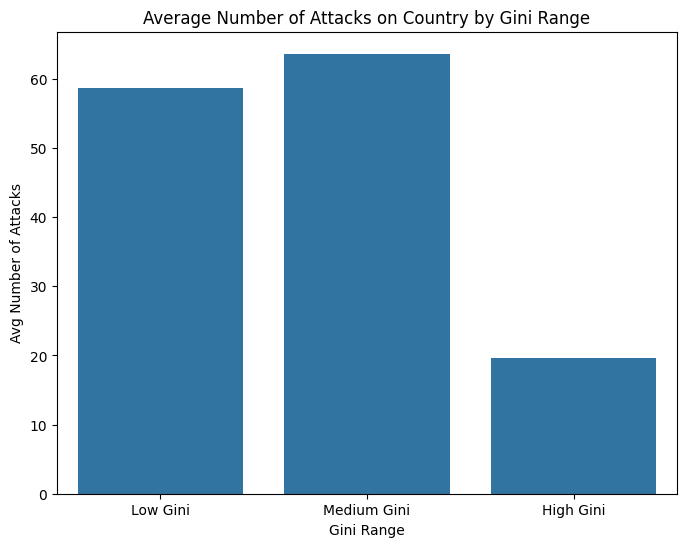

In [180]:
plt.figure(figsize=(8,6))
plt.title("Average Number of Attacks on Country by Gini Range")
sns.barplot(data=gini_range_comparison,x='Gini_Range',y='mean')
plt.xlabel('Gini Range')
plt.ylabel('Avg Number of Attacks')

In [181]:
merged_actor_cntry_data = actor_country_attacks.merge(gini_data,left_on='actor_country',right_on='country_name',how='inner')

In [182]:
merged_actor_cntry_data

,actor_country,num_attacks,country_name,gini
0,Albania,1,Albania,0.322512
1,Algeria,21,Algeria,0.334343
2,Armenia,1,Armenia,0.321028
3,Australia,4,Australia,0.335056
4,Austria,5,Austria,0.301773
...,...,...,...,...
57,Uganda,2,Uganda,0.426597
58,Ukraine,133,Ukraine,0.276594
59,United Arab Emirates,9,United Arab Emirates,0.294547
60,Uzbekistan,4,Uzbekistan,0.359525


In [183]:
merged_actor_cntry_data = merged_actor_cntry_data.drop(columns=['country_name'])

In [184]:
merged_actor_cntry_data

,actor_country,num_attacks,gini
0,Albania,1,0.322512
1,Algeria,21,0.334343
2,Armenia,1,0.321028
3,Australia,4,0.335056
4,Austria,5,0.301773
...,...,...,...
57,Uganda,2,0.426597
58,Ukraine,133,0.276594
59,United Arab Emirates,9,0.294547
60,Uzbekistan,4,0.359525


In [185]:
correlation,p_value = pearsonr(merged_actor_cntry_data['num_attacks'],merged_actor_cntry_data['gini'])

In [186]:
correlation

0.006249364696562907

In [187]:
p_value

0.9615516112558863

In [188]:

median_gini = merged_actor_cntry_data['gini'].median()
high_gini = merged_actor_cntry_data[merged_actor_cntry_data['gini'] > median_gini]['num_attacks']
low_gini = merged_actor_cntry_data[merged_actor_cntry_data['gini'] <= median_gini]['num_attacks']

In [189]:
t_stat,p_value_ttest = ttest_ind(high_gini,low_gini,equal_var = False)

In [190]:
t_stat

0.7439424708537664

In [191]:
p_value_ttest

0.4625324438624525

# Time Series

In [192]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose

MessageError: Error: credential propagation was unsuccessful

In [194]:
df = original_df
df['event_date'] = pd.to_datetime(df['event_date'], format='mixed')

df.set_index('event_date', inplace=True)
freq5Df = df.resample('5D').size().reset_index(name='count')
freq10Df = df.resample('10D').size().reset_index(name='count')
freq30Df = df.resample('30D').size().reset_index(name='count')
freq90Df = df.resample('90D').size().reset_index(name='count')

freq10Df.drop(freq10Df.tail(1).index,inplace=True)
freq5Df.drop(freq5Df.tail(1).index,inplace=True)
freq30Df.drop(freq30Df.tail(1).index,inplace=True)
freq90Df.drop(freq90Df.tail(1).index,inplace=True)

In [195]:
freq5Df

,event_date,count
0,2014-01-01,14
1,2014-01-06,14
2,2014-01-11,11
3,2014-01-16,22
4,2014-01-21,13
...,...,...
761,2024-06-02,18
762,2024-06-07,12
763,2024-06-12,13
764,2024-06-17,12


In [196]:
pip install pmdarima

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 26.8 MB/s eta 0:00:00


In [197]:
# Predictive Modeling
from pmdarima import auto_arima

data = freq5Df
data['event_date'] = pd.to_datetime(data['event_date'])
data = data.set_index('event_date')
data = data.resample('D').mean().interpolate()

train = data[:'2024-06-01']
test = data['2024-06-02':]

model = auto_arima(train['count'],seasonal=False,trace=True)

forecast = model.predict(n_periods=len(test))

/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning:

'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.

/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning:

'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.

/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning:

'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.

/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning:

'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.

/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning:

'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.

/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning:

'force_all

Performing stepwise search to minimize aic
 ARIMA(2,1,2)(0,0,0)[0] intercept   : AIC=inf, Time=12.57 sec
 ARIMA(0,1,0)(0,0,0)[0] intercept   : AIC=17517.912, Time=0.15 sec


/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning:

'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.

/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning:

'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.



 ARIMA(1,1,0)(0,0,0)[0] intercept   : AIC=14797.408, Time=0.43 sec


/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning:

'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.



...

/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning:

'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.



 ARIMA(4,1,0)(0,0,0)[0]             : AIC=14297.321, Time=0.41 sec


/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning:

'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.



 ARIMA(4,1,2)(0,0,0)[0]             : AIC=14127.380, Time=1.33 sec

Best model:  ARIMA(5,1,1)(0,0,0)[0]          
Total fit time: 51.659 seconds


/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning:

'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.



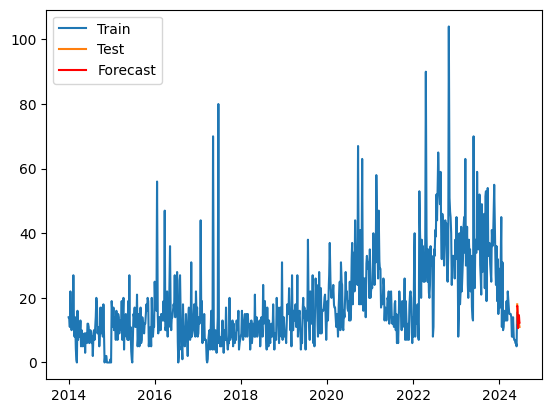

In [198]:
# Predictive Modeling Visualisation
plt.plot(train.index,train['count'],label='Train')
plt.plot(test.index,test['count'],label='Test')
plt.plot(test.index,forecast,label='Forecast',color='red')
plt.legend()
plt.show()

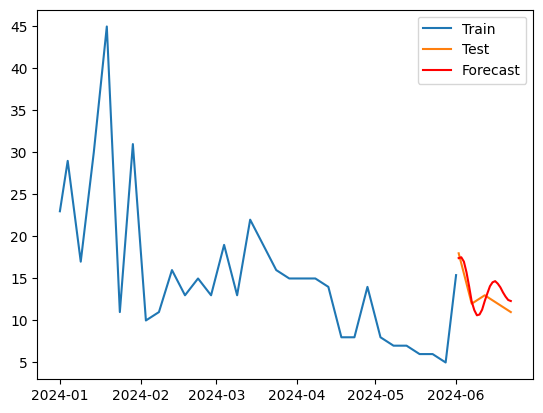

In [199]:
# zoom in
train_filtered = train[train.index >= '2024']
test_filtered = test[test.index >= '2024']
forecast_filtered = forecast[test.index >= '2024']

plt.plot(train_filtered.index, train_filtered['count'], label='Train')
plt.plot(test_filtered.index, test_filtered['count'], label='Test')
plt.plot(test_filtered.index, forecast_filtered, label='Forecast', color='red')
plt.legend()
plt.show()


In [200]:
# 10d
# Predictive Modeling
from pmdarima import auto_arima

data = freq10Df
data['event_date'] = pd.to_datetime(data['event_date'])
data = data.set_index('event_date')
data = data.resample('D').mean().interpolate()

train = data[:'2024-06-01']
test = data['2024-06-02':]

model = auto_arima(train['count'],seasonal=False,trace=True)

forecast = model.predict(n_periods=len(test))

/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning:

'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.

/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning:

'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.

/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning:

'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.

/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning:

'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.

/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning:

'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.

/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning:

'force_all

Performing stepwise search to minimize aic
 ARIMA(2,1,2)(0,0,0)[0] intercept   : AIC=10185.709, Time=10.43 sec
 ARIMA(0,1,0)(0,0,0)[0] intercept   : AIC=15381.073, Time=0.14 sec


/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning:

'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.

/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning:

'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.



 ARIMA(1,1,0)(0,0,0)[0] intercept   : AIC=10446.219, Time=0.51 sec


/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning:

'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.



...

/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning:

'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.



 ARIMA(3,1,1)(0,0,0)[0]             : AIC=10185.154, Time=0.92 sec


/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning:

'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.



 ARIMA(3,1,3)(0,0,0)[0]             : AIC=inf, Time=3.10 sec

Best model:  ARIMA(2,1,2)(0,0,0)[0]          
Total fit time: 81.005 seconds


/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning:

'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.



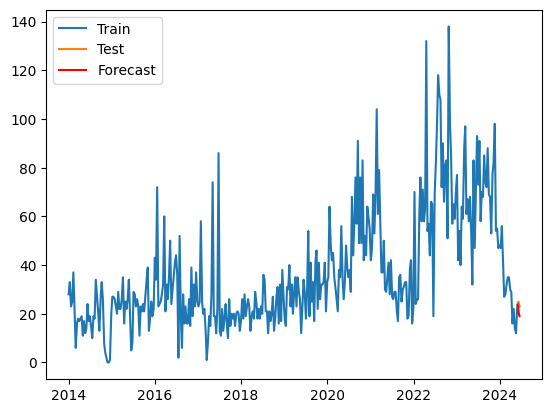

In [201]:
# Predictive Modeling Visualisation
plt.plot(train.index,train['count'],label='Train')
plt.plot(test.index,test['count'],label='Test')
plt.plot(test.index,forecast,label='Forecast',color='red')
plt.legend()
plt.show()

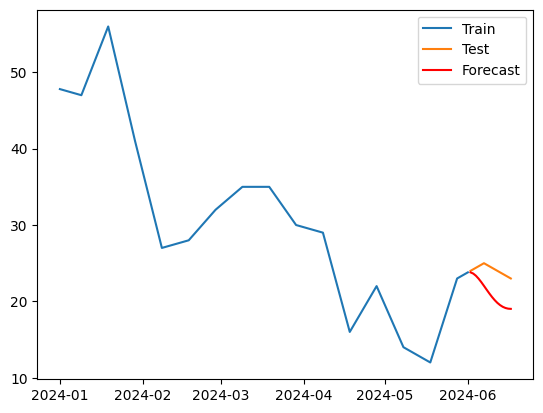

In [202]:
# zoom in
train_filtered = train[train.index >= '2024']
test_filtered = test[test.index >= '2024']
forecast_filtered = forecast[test.index >= '2024']

plt.plot(train_filtered.index, train_filtered['count'], label='Train')
plt.plot(test_filtered.index, test_filtered['count'], label='Test')
plt.plot(test_filtered.index, forecast_filtered, label='Forecast', color='red')
plt.legend()
plt.show()


In [203]:
freq30Df
sorted = freq30Df.sort_values(by='count')
sorted

,event_date,count
11,2014-11-27,1
10,2014-10-28,14
39,2017-03-16,28
2,2014-03-02,40
4,2014-05-01,40
...,...,...
101,2022-04-19,243
87,2021-02-23,244
105,2022-08-17,270
107,2022-10-16,288


In [204]:

# 30
# Predictive Modeling
from pmdarima import auto_arima

data = freq30Df
data['event_date'] = pd.to_datetime(data['event_date'])
data = data.set_index('event_date')
data = data.resample('D').mean().interpolate()

train = data[:'2024-06-01']
test = data['2024-06-02':]

model = auto_arima(train['count'],seasonal=False,trace=True)

forecast = model.predict(n_periods=len(test))

/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning:

'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.

/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning:

'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.

/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning:

'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.

/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning:

'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.

/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning:

'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.

/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning:

'force_all

Performing stepwise search to minimize aic
 ARIMA(2,1,2)(0,0,0)[0] intercept   : AIC=3400.490, Time=4.75 sec
 ARIMA(0,1,0)(0,0,0)[0] intercept   : AIC=12642.913, Time=0.07 sec


/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning:

'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.

/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning:

'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.



 ARIMA(1,1,0)(0,0,0)[0] intercept   : AIC=3451.304, Time=0.17 sec


/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning:

'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.



...

/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning:

'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.



 ARIMA(4,1,2)(0,0,0)[0] intercept   : AIC=inf, Time=6.49 sec


/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning:

'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.



 ARIMA(3,1,1)(0,0,0)[0]             : AIC=3452.913, Time=0.69 sec

Best model:  ARIMA(3,1,1)(0,0,0)[0] intercept
Total fit time: 33.595 seconds


ValueError: Prediction must have `end` after `start`.

ValueError: x and y must have same first dimension, but have shapes (0,) and (16,)

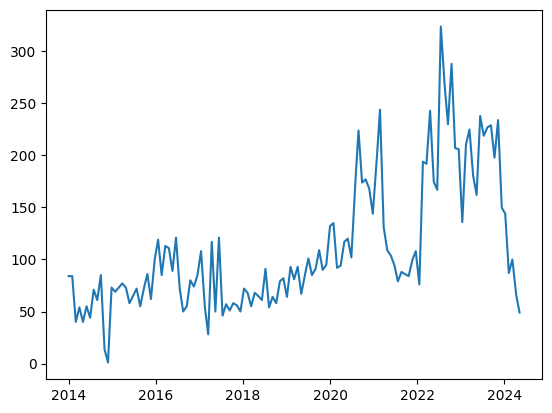

In [205]:
# Predictive Modeling Visualisation
plt.plot(train.index,train['count'],label='Train')
plt.plot(test.index,test['count'],label='Test')
plt.plot(test.index,forecast,label='Forecast',color='red')
plt.legend()
plt.show()

In [206]:
from pmdarima import auto_arima
import pandas as pd


data = freq30Df
data['event_date'] = pd.to_datetime(data['event_date'])
data = data.set_index('event_date')
data = data.resample('D').mean().interpolate()


train = data[:'2024-06-01']


model = auto_arima(train['count'], seasonal=False, trace=True)


last_date = train.index[-1]
forecast_end_date = '2025-06-30'
n_days_to_forecast = (pd.to_datetime(forecast_end_date) - last_date).days


forecast = model.predict(n_periods=n_days_to_forecast)


forecast_dates = pd.date_range(start=last_date + pd.Timedelta(days=1), periods=n_days_to_forecast)
forecast_df = pd.DataFrame({'forecast': forecast}, index=forecast_dates)


forecast_combined = pd.concat([data, forecast_df])

print(forecast_combined)


/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning:

'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.

/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning:

'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.

/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning:

'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.

/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning:

'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.

/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning:

'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.

/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning:

'force_all

Performing stepwise search to minimize aic
 ARIMA(2,1,2)(0,0,0)[0] intercept   : AIC=3400.490, Time=12.55 sec
 ARIMA(0,1,0)(0,0,0)[0] intercept   : AIC=12642.913, Time=0.07 sec


/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning:

'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.

/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning:

'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.



 ARIMA(1,1,0)(0,0,0)[0] intercept   : AIC=3451.304, Time=0.15 sec


/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning:

'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.



...

/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning:

'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.



 ARIMA(4,1,2)(0,0,0)[0] intercept   : AIC=inf, Time=6.97 sec


/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning:

'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.



 ARIMA(3,1,1)(0,0,0)[0]             : AIC=3452.913, Time=0.67 sec

Best model:  ARIMA(3,1,1)(0,0,0)[0] intercept
Total fit time: 42.716 seconds
            count   forecast
2014-01-01   84.0        NaN
2014-01-02   84.0        NaN
2014-01-03   84.0        NaN
2014-01-04   84.0        NaN
2014-01-05   84.0        NaN
...           ...        ...
2025-06-26    NaN  52.404478
2025-06-27    NaN  52.397321
2025-06-28    NaN  52.390164
2025-06-29    NaN  52.383007
2025-06-30    NaN  52.375850

[4199 rows x 2 columns]


/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning:

'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.



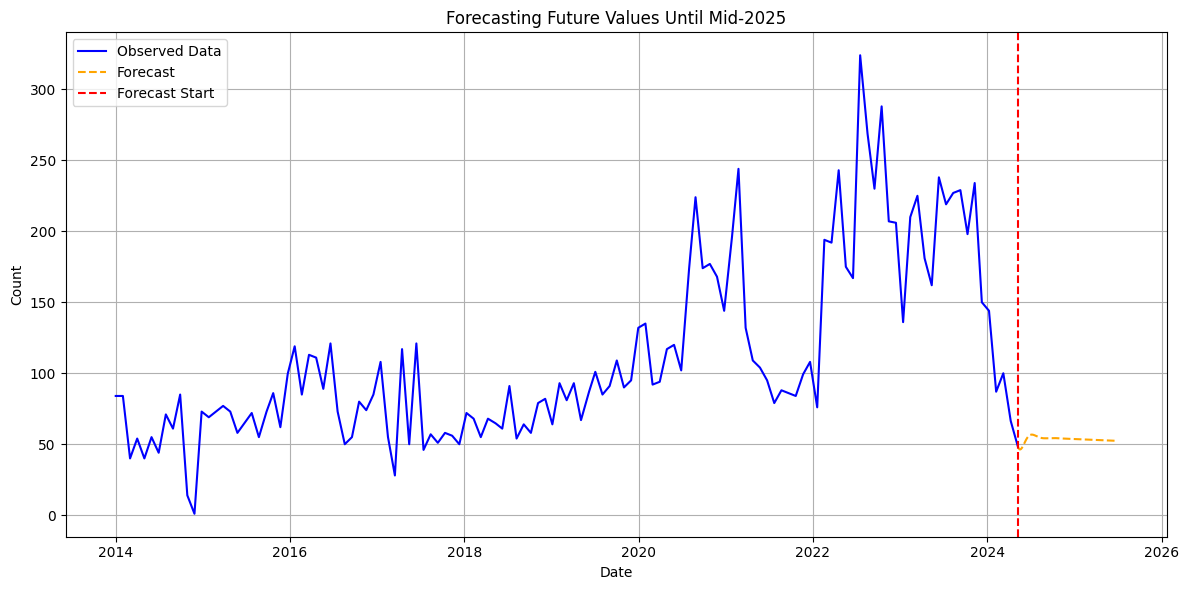

In [207]:
plt.figure(figsize=(12, 6))
plt.plot(data.index, data['count'], label='Observed Data', color='blue')
plt.plot(forecast_df.index, forecast_df['forecast'], label='Forecast', color='orange', linestyle='--')
plt.axvline(x=last_date, color='red', linestyle='--', label='Forecast Start')
plt.title('Forecasting Future Values Until Mid-2025')
plt.xlabel('Date')
plt.ylabel('Count')
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()

In [208]:
# 90

In [209]:
predictions_df = pd.DataFrame({
    'Date': test.index,
    'Actual': test['count'],
    'Predicted': forecast
}).reset_index(drop=True)

predictions_df

ValueError: array length 0 does not match index length 418

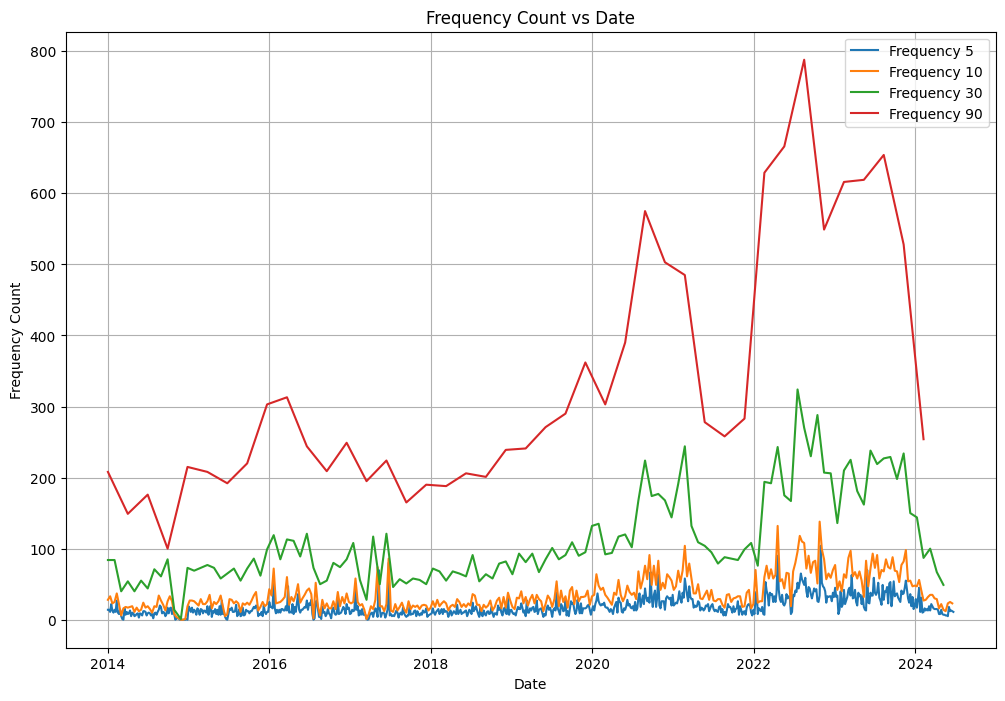

In [210]:
plt.figure(figsize=(12, 8))
plt.plot(freq5Df["event_date"], freq5Df["count"], label="Frequency 5")
plt.plot(freq10Df["event_date"], freq10Df["count"], label="Frequency 10")
plt.plot(freq30Df["event_date"], freq30Df["count"], label="Frequency 30")
plt.plot(freq90Df["event_date"], freq90Df["count"], label="Frequency 90")
plt.xlabel("Date")
plt.ylabel("Frequency Count")
plt.title("Frequency Count vs Date")
plt.legend()
plt.grid(True)
plt.show()

In [211]:
s30.values

NameError: name 's30' is not defined

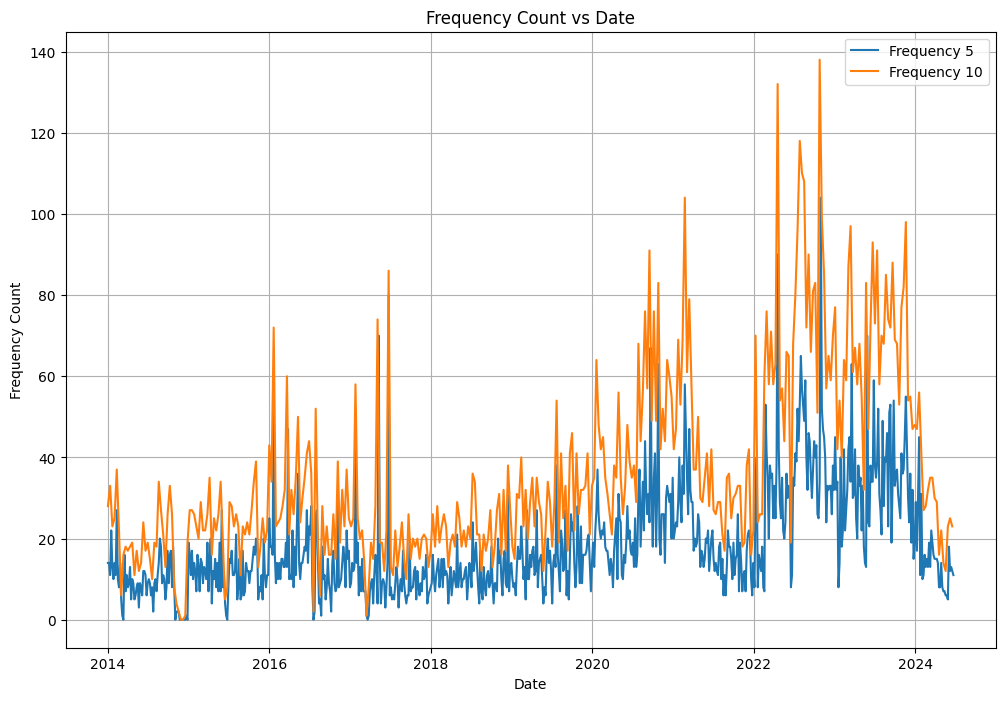

In [212]:
plt.figure(figsize=(12, 8))
plt.plot(freq5Df["event_date"], freq5Df["count"], label="Frequency 5")
plt.plot(freq10Df["event_date"], freq10Df["count"], label="Frequency 10")
plt.xlabel("Date")
plt.ylabel("Frequency Count")
plt.title("Frequency Count vs Date")
plt.legend()
plt.grid(True)
plt.show()

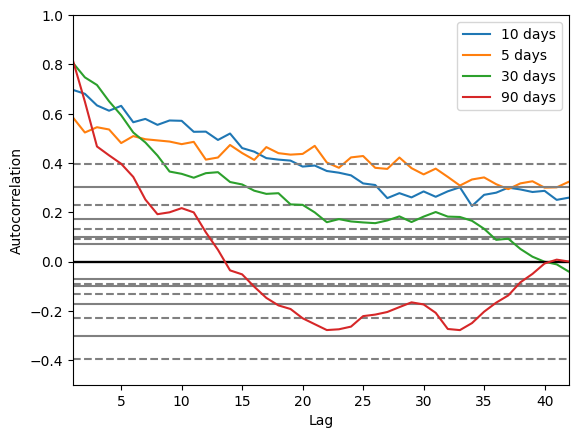

In [213]:
from pandas import read_csv
import pandas
from matplotlib import pyplot
from pandas.plotting import autocorrelation_plot

autocorrelation_plot(freq10Df['count'], label = '10 days')
autocorrelation_plot(freq5Df['count'], label = '5 days')
autocorrelation_plot(freq30Df['count'], label = '30 days')
autocorrelation_plot(freq90Df['count'], label = '90 days')
plt.ylim(-0.5, 1.0)
plt.legend()
plt.show()

/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning:

No frequency information was provided, so inferred frequency 10D will be used.

/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning:

No frequency information was provided, so inferred frequency 10D will be used.

/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning:

No frequency information was provided, so inferred frequency 10D will be used.

/usr/local/lib/python3.11/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning:

Maximum Likelihood optimization failed to converge. Check mle_retvals



                               SARIMAX Results                                
Dep. Variable:                  count   No. Observations:                  383
Model:                 ARIMA(3, 1, 4)   Log Likelihood                 310.457
Date:                Fri, 14 Feb 2025   AIC                           -604.914
Time:                        15:35:27   BIC                           -573.351
Sample:                    01-01-2014   HQIC                          -592.392
                         - 06-17-2024                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -1.1967      0.289     -4.136      0.000      -1.764      -0.630
ar.L2          0.0419      0.515      0.081      0.935      -0.968       1.052
ar.L3          0.5392      0.283      1.905      0.0

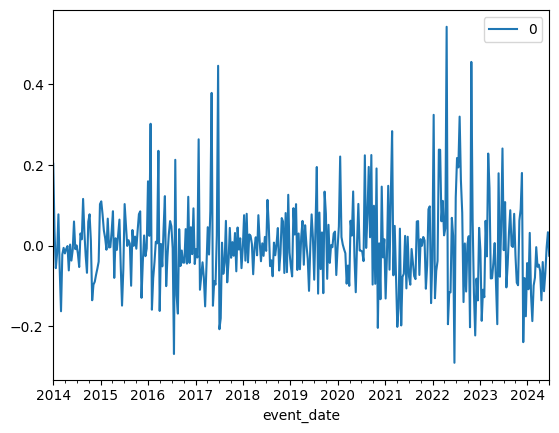

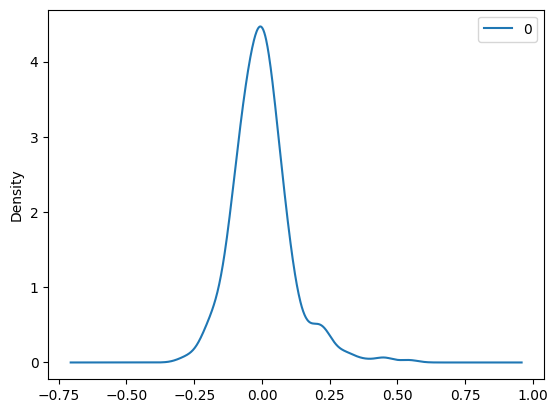

In [214]:
from statsmodels.tsa.arima.model import ARIMA
from matplotlib import pyplot
## arima on 10day period
s10 = freq10Df.set_index('event_date')
s10['count'] = (s10['count'] - s10['count'].min()) / (s10['count'].max() - s10['count'].min())
model = ARIMA(s10, order=(3,1,4))
model_fit = model.fit()
print(model_fit.summary())

residuals = pd.DataFrame(model_fit.resid)
residuals.plot()
pyplot.show()

residuals.plot(kind='kde')
pyplot.show()




In [ ]:
from sklearn.metrics import mean_squared_error
from math import sqrt
X = s10.values
size = int(len(X) * 0.66)
train, test = X[0:size], X[size:len(X)]
history = [x for x in train]
predictions = list()
# walk-forward validation
for t in range(len(test)):
	model = ARIMA(history, order=(3,1,4))
	model_fit = model.fit()
	output = model_fit.forecast()
	yhat = output[0]
	predictions.append(yhat)
	obs = test[t]
	history.append(obs)
	print('predicted=%f, expected=%f' % (yhat, obs))
# evaluate forecasts
rmse = sqrt(mean_squared_error(test, predictions))
print('Test RMSE: %.3f' % rmse)
# plot forecasts against actual outcomes
pyplot.plot(test)
pyplot.plot(predictions, color='red')
pyplot.show()

/usr/local/lib/python3.11/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning:

Maximum Likelihood optimization failed to converge. Check mle_retvals

<ipython-input-215-ac29567a6d00>:17: DeprecationWarning:

Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)



predicted=0.402610, expected=0.318841


/usr/local/lib/python3.11/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning:

Maximum Likelihood optimization failed to converge. Check mle_retvals



predicted=0.376604, expected=0.463768


/usr/local/lib/python3.11/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning:

Maximum Likelihood optimization failed to converge. Check mle_retvals



...

predicted=0.383718, expected=0.405797


/usr/local/lib/python3.11/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning:

Maximum Likelihood optimization failed to converge. Check mle_retvals



predicted=0.422863, expected=0.297101


/usr/local/lib/python3.11/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning:

Maximum Likelihood optimization failed to converge. Check mle_retvals



predicted=0.397328, expected=0.195652


In [ ]:
!pip install pmdarima

In [ ]:
import pandas as pd
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.arima.model import ARIMA
from pmdarima import auto_arima

auto_model = auto_arima(
    s10,
    seasonal=False,           # Set to True if seasonal component is suspected
    trace=True,               # Prints model details
    error_action='ignore',    # Ignores convergence errors
    suppress_warnings=True,   # Suppresses warnings
    stepwise=True             # Stepwise search for faster computation
)
print(f"Selected ARIMA order: {auto_model.order}")
print("Fitting the ARIMA model...")
model = ARIMA(s10, order=auto_model.order)
model_fit = model.fit()
print(model_fit.summary())


In [ ]:
X = s10.values
size = int(len(X) * 0.66)
train, test = X[0:size], X[size:len(X)]
history = [x for x in train]
predictions = list()
# walk-forward validation
for t in range(len(test)):
	model = ARIMA(history, order=(0,1,1))
	model_fit = model.fit()
	output = model_fit.forecast()
	yhat = output[0]
	predictions.append(yhat)
	obs = test[t]
	history.append(obs)
	print('predicted=%f, expected=%f' % (yhat, obs))
# evaluate forecasts
rmse = sqrt(mean_squared_error(test, predictions))
print('Test RMSE: %.3f' % rmse)
# plot forecasts against actual outcomes
pyplot.plot(test, label = 'data')
pyplot.plot(predictions, color='red', label = 'predictions')
pyplot.show()

In [ ]:
# Updated
from statsmodels.tsa.arima.model import ARIMA
from sklearn.preprocessing import StandardScaler
from pmdarima import auto_arima
from matplotlib import pyplot as plt
from math import sqrt
from sklearn.metrics import mean_squared_error
import numpy as np

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X.reshape(-1,1)).flatten()

size = int(len(X_scaled) * 0.66)
train,test = X_scaled[0:size], X_scaled[size:]

auto_model = auto_arima(train,seasonal=False,trace=True)
order = auto_model.order

history = [x for x in train]
predictions = []

for t in range(len(test)):
  model = ARIMA(history,order=order)
  model_fit = model.fit()
  output = model_fit.forecast()
  yhat = output[0]
  predictions.append(yhat)
  obs = test[t]
  history.append(obs)


rmse = sqrt(mean_squared_error(test,predictions))
print('Test RMSE',rmse)

plt.plot(test,label='Data')
plt.plot(predictions,color='red',label='Predictions')
plt.legend()
plt.show()

In [ ]:
s10

In [ ]:
s30 = freq30Df.set_index('event_date')
s30['count'] = (s30['count'] - s30['count'].min()) / (s30['count'].max() - s30['count'].min())

In [ ]:

auto_model = auto_arima(
    s30,
    seasonal=True,           # Set to True if seasonal component is suspected
    trace=True,               # Prints model details
    error_action='ignore',    # Ignores convergence errors
    suppress_warnings=True,   # Suppresses warnings
    stepwise=True             # Stepwise search for faster computation
)
print(f"Selected ARIMA order: {auto_model.order}")
print("Fitting the ARIMA model...")
model = ARIMA(s30, order=auto_model.order)
model_fit = model.fit()
print(model_fit.summary())


In [ ]:
X = s30.values
size = int(len(X) * 0.66)
train, test = X[0:size], X[size:len(X)]
history = [x for x in train]
predictions = list()
# walk-forward validation
for t in range(len(test)):
	model = ARIMA(history, order=(0,1,1))
	model_fit = model.fit()
	output = model_fit.forecast()
	yhat = output[0]
	predictions.append(yhat)
	obs = test[t]
	history.append(obs)
	print('predicted=%f, expected=%f' % (yhat, obs))
# evaluate forecasts
rmse = sqrt(mean_squared_error(test, predictions))
print('Test RMSE: %.3f' % rmse)
# plot forecasts against actual outcomes
pyplot.plot(test, label = 'data')
pyplot.plot(predictions, color='red', label = 'prediction')
pyplot.legend()
pyplot.show()

In [ ]:
X = s30.values
size = int(len(X) * 0.66)
train, test = X[0:size], X[size:len(X)]
history = [x for x in train]
predictions = list()
# walk-forward validation
for t in range(len(test)):
	model = ARIMA(history, order=(2,1,1))
	model_fit = model.fit()
	output = model_fit.forecast()
	yhat = output[0]
	predictions.append(yhat)
	obs = test[t]
	history.append(obs)
	print('predicted=%f, expected=%f' % (yhat, obs))
# evaluate forecasts
rmse = sqrt(mean_squared_error(test, predictions))
print('Test RMSE: %.3f' % rmse)
# plot forecasts against actual outcomes
pyplot.plot(test, label = 'data')
pyplot.plot(predictions, color='red', label = 'prediction')
pyplot.legend()
pyplot.show()

In [ ]:
s90 = freq90Df.set_index('event_date')
s90['count'] = (s90['count'] - s90['count'].min()) / (s90['count'].max() - s90['count'].min())

In [ ]:

auto_model = auto_arima(
    s90,
    seasonal=True,           # Set to True if seasonal component is suspected
    trace=True,               # Prints model details
    error_action='ignore',    # Ignores convergence errors
    suppress_warnings=True,   # Suppresses warnings
    stepwise=True             # Stepwise search for faster computation
)
print(f"Selected ARIMA order: {auto_model.order}")
print("Fitting the ARIMA model...")
model = ARIMA(s90, order=auto_model.order)
model_fit = model.fit()
print(model_fit.summary())

In [ ]:
X = s90.values
size = int(len(X) * 0.66)
train, test = X[0:size], X[size:len(X)]
history = [x for x in train]
predictions = list()
# walk-forward validation
for t in range(len(test)):
	model = ARIMA(history, order=(0,1,0))
	model_fit = model.fit()
	output = model_fit.forecast()
	yhat = output[0]
	predictions.append(yhat)
	obs = test[t]
	history.append(obs)
	print('predicted=%f, expected=%f' % (yhat, obs))
# evaluate forecasts
rmse = sqrt(mean_squared_error(test, predictions))
print('Test RMSE: %.3f' % rmse)
# plot forecasts against actual outcomes
pyplot.plot(test, label = 'data')
pyplot.plot(predictions, color='red', label = 'prediction')
pyplot.legend()
pyplot.show()

# Public Administration

In [ ]:
df_public_admin = df[df['industry'] == 'Public Administration']

In [ ]:
PAfreq10Df = df_public_admin.resample('10D').size().reset_index(name='count')
PAfreq30Df = df_public_admin.resample('30D').size().reset_index(name='count')

In [ ]:
plt.plot(PAfreq10Df["event_date"], PAfreq10Df["count"], label="Frequency 10")
plt.plot(PAfreq30Df["event_date"], PAfreq30Df["count"], label="Frequency 30")
plt.xlabel("Date")
plt.ylabel("Frequency Count")
plt.title("Frequency Count vs Date")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
from pandas import read_csv
import pandas
from matplotlib import pyplot
from pandas.plotting import autocorrelation_plot

autocorrelation_plot(PAfreq10Df['count'], label = '10 days')
autocorrelation_plot(PAfreq30Df['count'], label = '30 days')
plt.legend()
plt.show()

In [ ]:
PAs10 = PAfreq10Df.set_index('event_date')
PAs10['count'] = (PAs10['count'] - PAs10['count'].min()) / (PAs10['count'].max() - PAs10['count'].min())

In [ ]:
import pandas as pd
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.arima.model import ARIMA
from pmdarima import auto_arima

auto_model = auto_arima(
    PAs10,
    seasonal=True,           # Set to True if seasonal component is suspected
    trace=True,               # Prints model details
    error_action='ignore',    # Ignores convergence errors
    suppress_warnings=True,   # Suppresses warnings
    stepwise=True             # Stepwise search for faster computation
)
print(f"Selected ARIMA order: {auto_model.order}")
print("Fitting the ARIMA model...")
model = ARIMA(PAs10, order=auto_model.order)
model_fit = model.fit()
print(model_fit.summary())

import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf


residuals = model_fit.resid
plt.figure(figsize=(12, 6))
plt.subplot(211)
plt.plot(residuals)
plt.title("Residuals")
plt.subplot(212)
plt.hist(residuals, bins=20)
plt.title("Residual Histogram")
plt.tight_layout()
plt.show()


plot_acf(residuals, lags=30)
plt.title("Residuals ACF")
plt.show()

plot_pacf(residuals, lags=30)
plt.title("Residuals PACF")
plt.show()

In [ ]:
X = PAs10.values
size = int(len(X) * 0.66)
train, test = X[0:size], X[size:len(X)]
history = [x for x in train]
predictions = list()
# walk-forward validation
for t in range(len(test)):
	model = ARIMA(history, order=(1,1,1))
	model_fit = model.fit()
	output = model_fit.forecast()
	yhat = output[0]
	predictions.append(yhat)
	obs = test[t]
	history.append(obs)
	print('predicted=%f, expected=%f' % (yhat, obs))
# evaluate forecasts
rmse = sqrt(mean_squared_error(test, predictions))
print('Test RMSE: %.3f' % rmse)
# plot forecasts against actual outcomes
pyplot.plot(test, label = 'data')
pyplot.plot(predictions, color='red', label = 'prediction')
pyplot.legend()
pyplot.show()

In [ ]:
PAs30 = PAfreq30Df.set_index('event_date')
PAs30['count'] = (PAs30['count'] - PAs30['count'].min()) / (PAs30['count'].max() - PAs30['count'].min())

In [ ]:
import pandas as pd
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.arima.model import ARIMA
from pmdarima import auto_arima

auto_model = auto_arima(
    PAs30,
    seasonal=True,           # Set to True if seasonal component is suspected
    trace=True,               # Prints model details
    error_action='ignore',    # Ignores convergence errors
    suppress_warnings=True,   # Suppresses warnings
    stepwise=True             # Stepwise search for faster computation
)
print(f"Selected ARIMA order: {auto_model.order}")
print("Fitting the ARIMA model...")
model = ARIMA(PAs30, order=auto_model.order)
model_fit = model.fit()
print(model_fit.summary())

import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf


residuals = model_fit.resid
plt.figure(figsize=(12, 6))
plt.subplot(211)
plt.plot(residuals)
plt.title("Residuals")
plt.subplot(212)
plt.hist(residuals, bins=20)
plt.title("Residual Histogram")
plt.tight_layout()
plt.show()


plot_acf(residuals, lags=30)
plt.title("Residuals ACF")
plt.show()

plot_pacf(residuals, lags=30)
plt.title("Residuals PACF")
plt.show()

In [ ]:
X = PAs30.values
size = int(len(X) * 0.66)
train, test = X[0:size], X[size:len(X)]
history = [x for x in train]
predictions = list()
# walk-forward validation
for t in range(len(test)):
	model = ARIMA(history, order=(0,1,1))
	model_fit = model.fit()
	output = model_fit.forecast()
	yhat = output[0]
	predictions.append(yhat)
	obs = test[t]
	history.append(obs)
	print('predicted=%f, expected=%f' % (yhat, obs))
# evaluate forecasts
rmse = sqrt(mean_squared_error(test, predictions))
print('Test RMSE: %.3f' % rmse)
# plot forecasts against actual outcomes
pyplot.plot(test, label = 'data')
pyplot.plot(predictions, color='red', label = 'prediction')
pyplot.legend()
pyplot.show()